# SIAM: 一维安德森杂质链（总 10 个 site）

本 notebook 仿照 `docs/tutorials/lattice-fermions.ipynb`，用 NetKet 构造你给出的 SIAM 哈密顿量。

这里采用：杂质 1 个 site + 导带 9 个 site = 总 10 个 site。

索引约定：杂质轨道 `d` 在站点 0，导带链站点为 1..L，因此 `c0` 对应全局站点 1。

In [72]:
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)

NetKet version: 3.21.1.dev13+gbf43effcb


## 1) 定义链与 Hilbert 空间

In [73]:
L = 3  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))

chain nodes = 3 , chain edges = 2
n_orbitals = 4
fixed particles (N_up, N_dn) = (2, 2)


## 2) 参数（单独一段，便于调试）

In [74]:
U = 4.0

# Wilson chain 参数
D = 1.0
Lambda = 2.0
V = 0.15

# t_j, j = 0, 1, 2, ..., L-2
j = np.arange(0, L-1, dtype=float)
ti = (
    ((1.0 + Lambda**-1.0) * (1.0 - Lambda**(-j - 1.0)))
    / (
        2.0
        * np.sqrt(1.0 - Lambda**(-2.0 * j - 1.0))
        * np.sqrt(1.0 - Lambda**(-2.0 * j - 3.0))
    )
    * Lambda**(-j / 2.0)
    * D
)
print('ti =', ti)

ti = [0.56694671 0.43201382]


## 3) 构造 SIAM 哈密顿量

In [75]:
H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5) -0.25 * U  # 常数项使得半填充时能量为0

# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H

FermionOperator2ndJax(hilbert=SpinOrbitalFermions(n_orbitals=4, s=1/2, n_fermions=4, n_fermions_per_spin=(2, 2)), n_operators=15, dtype=float64)

## 4) 简单检查

In [76]:
print('max_conn_size =', H.max_conn_size)
print('ti length =', len(ti), '(expected L-1 =', L - 1, ')')

max_conn_size = 13
ti length = 2 (expected L-1 = 2 )


D:\Seafile\PHD\NQS\NetKet\netket\netket\operator\_fermion2nd\jax.py:557: UserWarning: 
Consider using `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd` to reduce the number of connected elements and
considerably reduce the computational cost.
You can convert this operator by calling `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd`.

  super()._setup(self)


## 5) 画图：10 个 site 的 SIAM 晶格（杂质单独着色）

下面将杂质 site（0）标成红色，导带 site（1..L）标成蓝色。

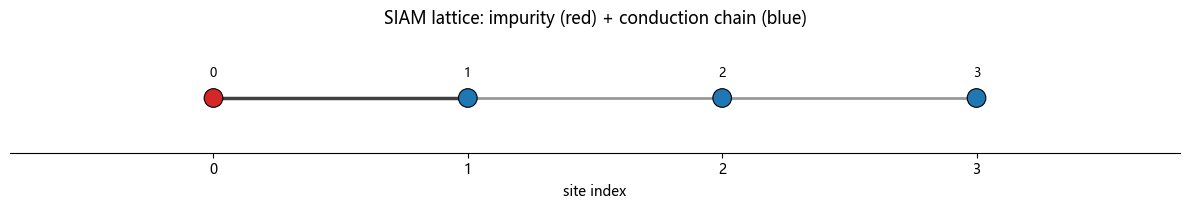

In [77]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

In [78]:
from math import comb
from scipy.sparse.linalg import eigsh
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# 直接复用第 3 段已构造好的 H（其 Hilbert 空间已固定粒子数）
N_up_ed, N_dn_ed = N_up, N_dn
sector_dim = comb(n_orbitals, N_up_ed) * comb(n_orbitals, N_dn_ed)
max_dim_for_sparse_ed = 2000000  # 经验阈值，可按机器内存调整

print("ED sector (N_up, N_dn) =", (N_up_ed, N_dn_ed))
print("Estimated Hilbert dimension =", sector_dim)

if sector_dim > max_dim_for_sparse_ed:
    print(
        "[Skip ED] 该扇区维度过大，不执行 to_sparse()/eigsh 以避免内存溢出。"
    )
    print("建议: 减小粒子数（如 1,1 或 2,2）后再做严格对角化。")
else:
    H_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    sp_h = H_ed.to_sparse()
    eig_vals, eig_vecs = eigsh(sp_h, k=4, which="SA")
    eig_vals = np.sort(np.real(eig_vals))

    print("Hilbert dimension in this sector =", sp_h.shape[0])
    print("Exact ground-state energy E0 =", eig_vals[0])
    print("Lowest 4 eigenvalues =", eig_vals)

ED sector (N_up, N_dn) = (2, 2)
Estimated Hilbert dimension = 36
Hilbert dimension in this sector = 36
Exact ground-state energy E0 = -3.4474596673821134
Lowest 4 eigenvalues = [-3.44745967 -3.43086174 -2.73570886 -2.73498395]


## 6) 严格对角化（ED）

参照 `lattice-fermions.ipynb` 的思路：先把哈密顿量转为稀疏矩阵，再用 `scipy.sparse.linalg.eigsh` 求低能本征值。

注意：对 10 个 site 的自旋费米子，若不固定粒子数，Hilbert 空间仍可能较大。这里在固定粒子数扇区做严格对角化。

Computing G from ED ground state, size 8x8...
Done computing G.


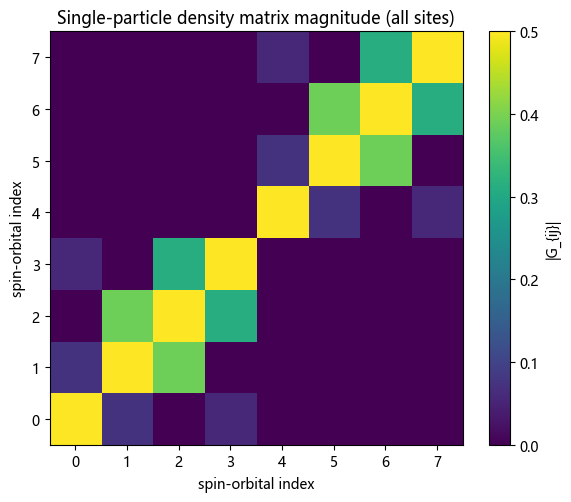

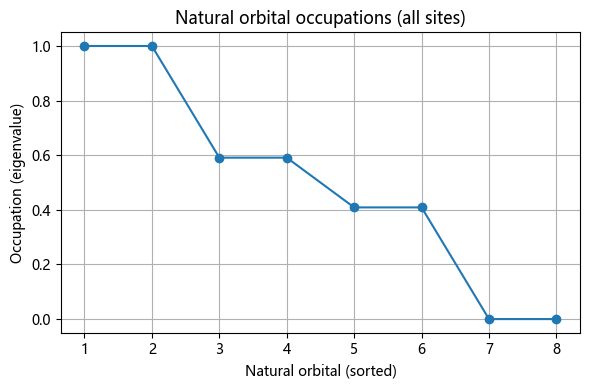

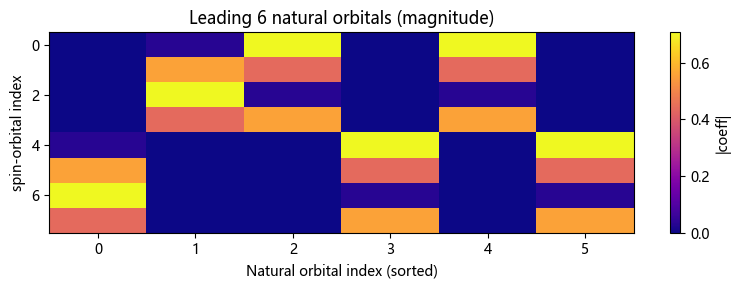

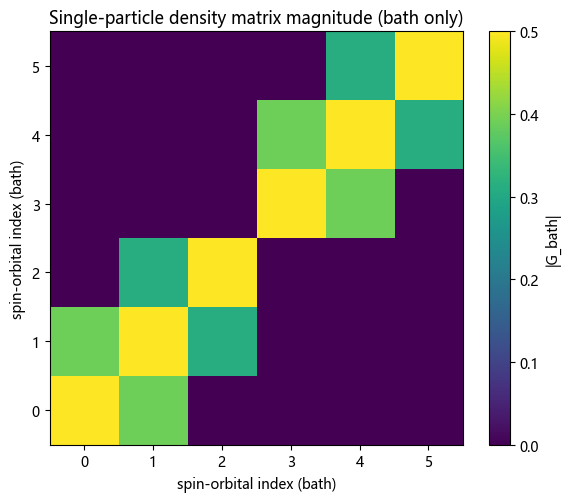

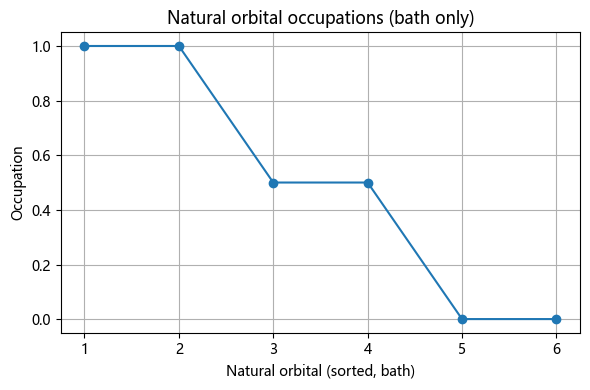

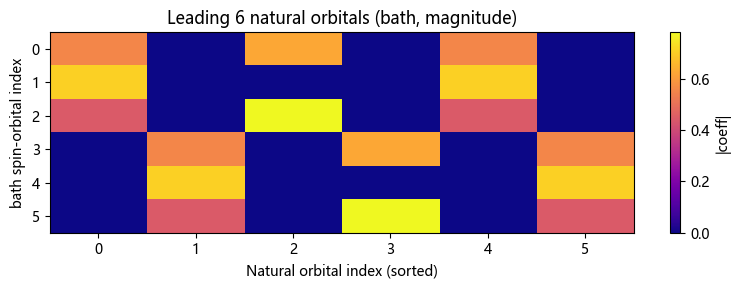

In [79]:
# --- 从 ED 基态构造单体密度矩阵并绘图（全体 & 去除杂质） ---
import numpy as np
import matplotlib.pyplot as plt
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd
from netket.operator.fermion import create as cdag, destroy as c

# 取 ED 基态向量（eig_vecs 应在前一单元中生成）
psi0 = eig_vecs[:, 0]
n_orb = hi.n_orbitals
n_ob = 2 * n_orb
print(f"Computing G from ED ground state, size {n_ob}x{n_ob}...")

# 仅计算同自旋块以避免转换 spin-flip 运算符时出错
G = np.zeros((n_ob, n_ob), dtype=np.complex128)
for sz in (+1, -1):
    off = 0 if sz == +1 else n_orb
    for i in range(n_orb):
        for j in range(n_orb):
            op = cdag(hi, i, sz=sz) @ c(hi, j, sz=sz)
            op_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op)
            sp = op_ed.to_sparse()
            G[off + i, off + j] = psi0.conj().T @ (sp @ psi0)

print('Done computing G.')

# 1) 全体格点：矩阵分布、对角化、自然轨道与占据数（降序）
plt.figure(figsize=(6,5))
plt.imshow(np.abs(G), origin='lower', cmap='viridis')
plt.colorbar(label='|G_{ij}|')
plt.title('Single-particle density matrix magnitude (all sites)')
plt.xlabel('spin-orbital index')
plt.ylabel('spin-orbital index')
plt.tight_layout()
plt.show()

evals, evecs = np.linalg.eigh(G)
order = np.argsort(-evals.real)
evals_sorted = evals[order].real
evecs_sorted = evecs[:, order]

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(evals_sorted)+1), evals_sorted, 'o-')
plt.xlabel('Natural orbital (sorted)')
plt.ylabel('Occupation (eigenvalue)')
plt.title('Natural orbital occupations (all sites)')
plt.grid(True)
plt.tight_layout()
plt.show()

n_show = min(6, evecs_sorted.shape[1])
plt.figure(figsize=(8,3))
plt.imshow(np.abs(evecs_sorted[:, :n_show]), aspect='auto', cmap='plasma')
plt.colorbar(label='|coeff|')
plt.xlabel('Natural orbital index (sorted)')
plt.ylabel('spin-orbital index')
plt.title(f'Leading {n_show} natural orbitals (magnitude)')
plt.tight_layout()
plt.show()

# 2) 去掉杂质后的子空间（仅 bath）并重复分析
imp = impurity_site
bath_orbs = [k for k in range(n_orb) if k != imp]
bath_indices = [k for k in bath_orbs] + [k + n_orb for k in bath_orbs]
G_bath = G[np.ix_(bath_indices, bath_indices)]

plt.figure(figsize=(6,5))
plt.imshow(np.abs(G_bath), origin='lower', cmap='viridis')
plt.colorbar(label='|G_bath|')
plt.title('Single-particle density matrix magnitude (bath only)')
plt.xlabel('spin-orbital index (bath)')
plt.ylabel('spin-orbital index (bath)')
plt.tight_layout()
plt.show()

evals_b, evecs_b = np.linalg.eigh(G_bath)
order_b = np.argsort(-evals_b.real)
evals_b_sorted = evals_b[order_b].real
evecs_b_sorted = evecs_b[:, order_b]

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(evals_b_sorted)+1), evals_b_sorted, 'o-')
plt.xlabel('Natural orbital (sorted, bath)')
plt.ylabel('Occupation')
plt.title('Natural orbital occupations (bath only)')
plt.grid(True)
plt.tight_layout()
plt.show()

n_show_b = min(6, evecs_b_sorted.shape[1])
plt.figure(figsize=(8,3))
plt.imshow(np.abs(evecs_b_sorted[:, :n_show_b]), aspect='auto', cmap='plasma')
plt.colorbar(label='|coeff|')
plt.xlabel('Natural orbital index (sorted)')
plt.ylabel('bath spin-orbital index')
plt.title(f'Leading {n_show_b} natural orbitals (bath, magnitude)')
plt.tight_layout()
plt.show()

# 输出结果到变量，便于后续使用
G_matrix = G
G_bath_matrix = G_bath
natural_occupations_all = evals_sorted
natural_occupations_bath = evals_b_sorted

### SIAM 哈密顿量（LaTeX 表达式）及自然轨道基下的变换

下面给出本 notebook 中使用的单杂质安德森模型（SIAM）哈密顿量的公式：

$$
H = U\,(n_{d\uparrow}-\tfrac{1}{2})(n_{d\downarrow}-\tfrac{1}{2})
\; + \; V\sum_{\sigma=\uparrow,\downarrow}\left(d^{\dagger}_{\sigma}\,c_{0\sigma} + c^{\dagger}_{0\sigma}\,d_{\sigma}\right)
\; + \; \sum_{\sigma=\uparrow,\downarrow}\sum_{i=1}^{L-1} t_i\left(c^{\dagger}_{i\sigma}\,c_{i-1,\sigma} + \mathrm{h.c.}\right)
$$

下面写出把算符从原局域自旋轨道基 $\{c_{p\sigma}\}$ 变换到自然轨道基 $\{a_{\alpha\sigma}\}$ 的通用单体线性变换：

$$
a_{\alpha\sigma} = \sum_{p} U_{p\alpha}\,c_{p\sigma},\qquad c_{p\sigma} = \sum_{\alpha} U^{*}_{p\alpha}\,a_{\alpha\sigma},
$$

其中 $U$ 为从原基到自然轨道基的酉变换矩阵（由格林函数对角化得到的本征向量构成列向量）。下述给出两种情形的哈密顿量形式：

**情形 A：对全体自旋轨道（含杂质）做自然轨道变换**

- 1 体项（动能、跃迁、混成在一体项中可统一写作）在新基下的形式：

$$
H_{1} = \sum_{pq,\sigma} h_{pq}\,c^{\dagger}_{p\sigma}c_{q\sigma}
= \sum_{\alpha\beta,\sigma} h'_{\alpha\beta}\,a^{\dagger}_{\alpha\sigma}a_{\beta\sigma},
\\
h' = U^{\dagger} h \, U,
$$

- 杂质的库仑 2 体项在自然轨道基中将变成一般的二体（四指标）形式。例如原项 $U(n_{d\uparrow}-\tfrac12)(n_{d\downarrow}-\tfrac12)$ 可写为：

$$
H_{U} = U\left(\sum_{\alpha\beta} U^{*}_{d\alpha}U_{d\beta}a^{\dagger}_{\alpha\uparrow}a_{\beta\uparrow}-\tfrac12\right)\left(\sum_{\gamma\delta} U^{*}_{d\gamma}U_{d\delta}a^{\dagger}_{\gamma\downarrow}a_{\delta\downarrow}-\tfrac12\right),
$$

这会展开为包含诸多 $a^{\dagger}a^{\dagger}aa$ 型项的等价二体相互作用（在数值上可按展开后的系数构造）。

- 因此总体在自然轨道基下的哈密顿量写为：

$$
H = \sum_{\alpha\beta,\sigma} h'_{\alpha\beta}\,a^{\dagger}_{\alpha\sigma}a_{\beta\sigma} \, + \, \frac{1}{2}\sum_{\alpha\beta\gamma\delta}\sum_{\sigma\sigma'} V_{\alpha\beta\gamma\delta}^{\,\sigma\sigma'}\,a^{\dagger}_{\alpha\sigma}a^{\dagger}_{\beta\sigma'}a_{\gamma\sigma'}a_{\delta\sigma},
$$

其中四指标相互作用张量 $V_{\alpha\beta\gamma\delta}^{\,\sigma\sigma'}$ 可由原始局域相互作用与 $U$ 的展开系数得到。

**情形 B：仅对导带（bath）站点做自然轨道变换，杂质轨道保持不变**

记原导带局域算符为 $c_{i\sigma}$（局部索引 $i$，其中 $i=0$ 为首站点与杂质混成），把导带轨道变换为新的导带自然轨道 $b_{m\sigma}$：

$$
b_{m\sigma} = \sum_{i\in\mathrm{bath}} W_{i m}\,c_{i\sigma},\qquad c_{i\sigma}=\sum_{m} W^{*}_{i m}\,b_{m\sigma},
$$

这里 $W$ 是仅在导带子空间上的酉矩阵；杂质算符仍用 $d_{\sigma}$ 表示。变换后各项：

- 混成项：

$$
V\sum_{\sigma}\left(d^{\dagger}_{\sigma}c_{0\sigma}+\mathrm{h.c.}\right)
= V\sum_{\sigma}\sum_{m} W^{*}_{0m}\,d^{\dagger}_{\sigma}b_{m\sigma} + \mathrm{h.c.},
$$

因此混成耦合分布到各个导带自然轨道，耦合强度为 $V\,W^{*}_{0m}$.

- 导带的 1 体项（动能/跃迁）在新导带基下为：

$$
H_{\mathrm{bath},1} = \sum_{ij\in\mathrm{bath},\sigma} h_{ij}\,c^{\dagger}_{i\sigma}c_{j\sigma}
= \sum_{mn,\sigma} h^{(b)}_{mn}\,b^{\dagger}_{m\sigma}b_{n\sigma},\\
h^{(b)} = W^{\dagger} h^{(\mathrm{bath})} W.
$$

- 杂质库仑项保持局域（形式不变），但若需要以导带自然轨道表示杂质电子与导带电子的二体耦合，也可展开得到相应的四指标项。

总结：

- 对全体站点做自然轨道变换会将一体项对角化或带来紧耦合的一体矩阵 $h'$，但会把局域 $U$ 项展开成广泛的四指标二体相互作用；

- 仅对导带做变换（杂质保持不变）则更为实用：一体项在导带上可能变简单（如对角化），混成项变为 $V W^{*}_{0m}$ 的形式，杂质的局域交互仍保留在局域形式，从而便于数值处理与截断。

### Cell 16 Notes: Build Transformed Hamiltonian Tensors (Case A / Case B)

This note describes Cell 17.
The goal is to build two transformed tensor sets from the SIAM Hamiltonian.

- Case A (full-site transform): rotate impurity and bath orbitals.
- Case B (bath-only transform): rotate bath orbitals, keep impurity unchanged.

Main steps in Cell 17:

1. Rebuild the original one-body matrix `h_spatial`, then expand to spin-orbital basis `h_spin`.
2. Build the original local interaction tensor `V_orig` with one nonzero impurity element.
3. Build transform matrices from `G_matrix` and `G_bath_matrix`:
   - `U_spin` for Case A
   - `U_full_B` for Case B
4. Apply the same 4-index transform formula to obtain `V_A` and `V_B`.
5. Save outputs:
   - `h_trans_full`, `V_trans_full`
   - `h_trans_bath`, `V_trans_bath`
6. Save `transform_meta` for consistency checks in the ED spectrum cell.

Notebook state warning:

- Jupyter keeps variables in memory across cells.
- If cells are run out of order, stale variables can produce wrong spectra without errors.
- Recommended order: run Cell 17 first, then Cell 19.



In [80]:
import numpy as np
from scipy.linalg import block_diag
import netket as nk
from netket.operator.fermion import create as cdag, destroy as c

# =====================================================================
# 0. 依赖项检查
# =====================================================================
required = ['hi', 'chain', 'ti', 'impurity_site', 'conduction_offset', 'V', 'U', 'G_matrix', 'G_bath_matrix']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f'Missing required variables: {missing}. 请先运行前面定义物理参数的 Cell。')

print("--- 开始重构哈密顿量张量与 NetKet 算符 ---")

# =====================================================================
# 1. 构建原始实空间哈密顿量张量 (Original H)
# =====================================================================
n_orb = hi.n_orbitals
n_ob = 2 * n_orb
h_spatial = np.zeros((n_orb, n_orb), dtype=float)

# (a) 杂质与导带首站点混成 (V)
c0_site = conduction_offset
h_spatial[impurity_site, c0_site] += V
h_spatial[c0_site, impurity_site] += V

# (b) 导带内部的跳跃 (t)
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]
    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset
    h_spatial[left_site, right_site] += t_bond
    h_spatial[right_site, left_site] += t_bond

# 扩展到自旋轨道基底 (前半部分为 sz=+1，后半部分为 sz=-1)
h_spin = block_diag(h_spatial, h_spatial)

# 展开 U(n_up - 0.5)(n_dn - 0.5)
imp_up = impurity_site
imp_dn = impurity_site + n_orb

h_spin[imp_up, imp_up] -= U / 2.0
h_spin[imp_dn, imp_dn] -= U / 2.0
const_term = U / 4.0

V_orig = np.zeros((n_ob, n_ob, n_ob, n_ob), dtype=complex)
# U cdag_up cdag_dn c_dn c_up 严格等于 U n_up n_dn
V_orig[imp_up, imp_dn, imp_dn, imp_up] = U

# =====================================================================
# 2. Case A (全轨道旋转) 与 Case B (仅 Bath 旋转)
# =====================================================================
# Case A
G_up = G_matrix[:n_orb, :n_orb]
eig_sp, evec_sp = np.linalg.eigh(G_up)
order_sp = np.argsort(-eig_sp.real)
U_spin = block_diag(evec_sp[:, order_sp], evec_sp[:, order_sp])

h_A = U_spin.conj().T @ h_spin @ U_spin
V_A = np.einsum('pA,qB,rC,sD,pqrs->ABCD', U_spin.conj(), U_spin.conj(), U_spin, U_spin, V_orig, optimize=True)

# Case B
G_bath_up = G_bath_matrix[:n_orb-1, :n_orb-1]
eig_b, evec_b = np.linalg.eigh(G_bath_up)
order_b = np.argsort(-eig_b.real)

U_full_B = np.eye(n_ob, dtype=complex)
bath_idx = [k for k in range(n_orb) if k != impurity_site]
U_full_B[np.ix_(bath_idx, bath_idx)] = evec_b[:, order_b]
U_full_B[np.ix_([k+n_orb for k in bath_idx], [k+n_orb for k in bath_idx])] = evec_b[:, order_b]

h_B = U_full_B.conj().T @ h_spin @ U_full_B
V_B = np.einsum('pA,qB,rC,sD,pqrs->ABCD', U_full_B.conj(), U_full_B.conj(), U_full_B, U_full_B, V_orig, optimize=True)

# =====================================================================
# 4. 定义代数构建函数 (完全免疫索引 Bug)
# =====================================================================
def build_netket_operator_algebraic(hilbert, h_mat, V_tens, const_val=0.0, threshold=1e-12, name="Operator"):
    n_orb = hilbert.n_orbitals
    
    # 预先生成所有的单粒子算符，严格按照我们 block_diag 的逻辑赋 sz
    op_cdag = [cdag(hilbert, int(p % n_orb), sz=(+1 if p < n_orb else -1)) for p in range(2 * n_orb)]
    op_c    = [c(hilbert, int(p % n_orb), sz=(+1 if p < n_orb else -1)) for p in range(2 * n_orb)]
    
    # 初始化一个空的 FermionOperator2nd (避免 0.0 + op 引起类型报错)
    H_nk = 0.0 * op_cdag[0]
    
    # 累加单体项 (1-body)
    idx_1b = np.argwhere(np.abs(h_mat) > threshold)
    for idx in idx_1b:
        p, q = int(idx[0]), int(idx[1])
        val = h_mat[p, q]
        if np.abs(val.imag) < threshold: val = val.real
        H_nk += val * (op_cdag[p] @ op_c[q])
        
    # 累加双体项 (2-body)
    idx_2b = np.argwhere(np.abs(V_tens) > threshold)
    for idx in idx_2b:
        p, q, r, s = int(idx[0]), int(idx[1]), int(idx[2]), int(idx[3])
        val = V_tens[p, q, r, s]
        if np.abs(val.imag) < threshold: val = val.real
        H_nk += val * (op_cdag[p] @ op_cdag[q] @ op_c[r] @ op_c[s])
        
    # 加上常数项
    H_nk += const_val
    
    print(f"--- {name} 构建完成 (保留单体项: {len(idx_1b)}, 双体项: {len(idx_2b)}) ---")
    return H_nk

# =====================================================================
# 5. 生成最终的 NetKet 算符
# =====================================================================
print("\n>>> 开始使用代数方法构建 NetKet 算符 (处理数千项可能需要几秒钟，请稍候)...")

H_orig_nk = build_netket_operator_algebraic(hi, h_spin, V_orig, const_val=const_term, threshold=1e-12, name="Original H")
H_A_nk    = build_netket_operator_algebraic(hi, h_A,    V_A,    const_val=const_term, threshold=1e-12, name="Case A")
H_B_nk    = build_netket_operator_algebraic(hi, h_B,    V_B,    const_val=const_term, threshold=1e-12, name="Case B")

print("\n=== 所有哈密顿量构建完毕！请前往 ED 测试能谱 ===")

--- 开始重构哈密顿量张量与 NetKet 算符 ---

>>> 开始使用代数方法构建 NetKet 算符 (处理数千项可能需要几秒钟，请稍候)...
--- Original H 构建完成 (保留单体项: 14, 双体项: 1) ---
--- Case A 构建完成 (保留单体项: 32, 双体项: 256) ---
--- Case B 构建完成 (保留单体项: 26, 双体项: 1) ---

=== 所有哈密顿量构建完毕！请前往 ED 测试能谱 ===


### Cell 18 Notes: ED Spectrum Check (Reference vs Case A / Case B)

This note describes Cell 19.
Cell 19 verifies spectral equivalence between the original Hamiltonian and transformed Hamiltonians.

Main steps in Cell 19:

1. Rebuild one-body operators from `h_trans_full` and `h_trans_bath`.
2. Build Case A interaction using the same transform convention as Cell 17.
3. Build Case B interaction as local impurity U (impurity is unchanged in Case B).
4. Convert all operators to sparse matrices and compare low-energy eigenvalues.

Why Case A can fail while Case B matches:

- A common cause is stale notebook state:
  `U_spin`, `h_trans_full`, and `V_trans_full` may come from different runs.
- Cell 19 performs consistency checks using `transform_meta` to avoid silent mismatch.



In [81]:
# --- Reference spectrum vs Case A vs Case B (ED check; memory-safe) ---
import numpy as np
from math import comb
from scipy.sparse.linalg import eigsh
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

tol_spec = 1e-8
max_dim_for_sparse_ed = 2_000_000  # safety threshold; tune by available RAM

# 0) Dependency and consistency checks
# 确保上一步的这三个算符已经存在于内存中
required = ['hi', 'H_orig_nk', 'H_A_nk', 'H_B_nk', 'N_up', 'N_dn']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f'Missing required variables: {missing}. 请先运行上一步生成算符的代码。')

n_orb = hi.n_orbitals
N_up_ed, N_dn_ed = int(N_up), int(N_dn)
sector_dim = comb(n_orb, N_up_ed) * comb(n_orb, N_dn_ed)

print('--- ED 验证配置 ---')
print('ED sector (N_up, N_dn) =', (N_up_ed, N_dn_ed))
print('Estimated Hilbert dimension =', sector_dim)

if sector_dim > max_dim_for_sparse_ed:
    raise RuntimeError(
        f'[Skip ED] sector_dim={sector_dim} > max_dim_for_sparse_ed={max_dim_for_sparse_ed}. '
        'Reduce system size or particle numbers before running.'
    )
print("Dependency checks passed.\n")

# ==========================================
# 核心转换函数：将 NetKet 算符转换为守恒区间的稀疏矩阵
# ==========================================
def to_sector_sparse(op, label):
    print(f'Converting {label} to particle-number-conserving ED operator...')
    op_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op)
    print(f'Converting {label} to sparse matrix...')
    return op_ed.to_sparse()

# 1) 获取原始哈密顿量的稀疏矩阵 (Reference)
sp_ref = to_sector_sparse(H_orig_nk, 'Original H (H_orig_nk)')

# 2) 获取 Case A (全轨道旋转) 的稀疏矩阵
sp_A = to_sector_sparse(H_A_nk, 'Case A (H_A_nk)')

# 3) 获取 Case B (仅 Bath 旋转) 的稀疏矩阵
sp_B = to_sector_sparse(H_B_nk, 'Case B (H_B_nk)')

print(f"\nSparse Matrices Shape:")
print(f"  sp_ref shape = {sp_ref.shape}")
print(f"  sp_A   shape = {sp_A.shape}")
print(f"  sp_B   shape = {sp_B.shape}\n")

# ==========================================
# 求解最低能谱 (ED)
# ==========================================
N = sp_ref.shape[0]
if N <= 3:
    raise RuntimeError(f'ED matrix too small (N={N}) for eigsh with current setup.')

k = min(6, N - 2)
print(f'Computing lowest {k} eigenvalues for each Hamiltonian (this may take time)...')

# 使用 SciPy 的 eigsh 求解最低的 k 个本征值 (SA = Smallest Algebraic)
vals_ref = np.sort(np.real(eigsh(sp_ref, k=k, which='SA', return_eigenvectors=False)))
vals_A = np.sort(np.real(eigsh(sp_A, k=k, which='SA', return_eigenvectors=False)))
vals_B = np.sort(np.real(eigsh(sp_B, k=k, which='SA', return_eigenvectors=False)))

print('\n--- 能谱对比结果 (Eigenvalues) ---')
print('Reference lowest eigenvalues :', np.round(vals_ref, 8))
print('Case A lowest eigenvalues    :', np.round(vals_A, 8))
print('Case B lowest eigenvalues    :', np.round(vals_B, 8))

# ==========================================
# 精度验证
# ==========================================
eq_A = np.allclose(vals_ref, vals_A, atol=tol_spec, rtol=0)
eq_B = np.allclose(vals_ref, vals_B, atol=tol_spec, rtol=0)

print(f'\n--- 误差分析 (Tolerance = {tol_spec}) ---')
print('Case A spectrum matches reference:', eq_A)
print('Case B spectrum matches reference:', eq_B)
print('max|ref - A| =', np.max(np.abs(vals_ref - vals_A)))
print('max|ref - B| =', np.max(np.abs(vals_ref - vals_B)))

--- ED 验证配置 ---
ED sector (N_up, N_dn) = (2, 2)
Estimated Hilbert dimension = 36
Dependency checks passed.

Converting Original H (H_orig_nk) to particle-number-conserving ED operator...
Converting Original H (H_orig_nk) to sparse matrix...
Converting Case A (H_A_nk) to particle-number-conserving ED operator...
Converting Case A (H_A_nk) to sparse matrix...
Converting Case B (H_B_nk) to particle-number-conserving ED operator...
Converting Case B (H_B_nk) to sparse matrix...

Sparse Matrices Shape:
  sp_ref shape = (36, 36)
  sp_A   shape = (36, 36)
  sp_B   shape = (36, 36)

Computing lowest 6 eigenvalues for each Hamiltonian (this may take time)...

--- 能谱对比结果 (Eigenvalues) ---
Reference lowest eigenvalues : [-2.44745967 -2.43086174 -1.73570886 -1.73498395 -1.71965485 -1.7195475 ]
Case A lowest eigenvalues    : [-2.44745967 -2.43086174 -1.73570886 -1.73498395 -1.71965485 -1.7195475 ]
Case B lowest eigenvalues    : [-2.44745967 -2.43086174 -1.73570886 -1.73498395 -1.71965485 -1.7195475

In [82]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from functools import partial

from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# 如果第 6 段已执行，则直接复用基准能量；否则临时算一次（用于后续误差对比）
if "eig_vals" in globals():
    E_gs = float(np.sort(np.real(eig_vals))[0])
else:
    H_ref = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    from scipy.sparse.linalg import eigsh
    ref_vals, _ = eigsh(H_ref.to_sparse(), k=2, which="SA")
    E_gs = float(np.sort(np.real(ref_vals))[0])

print("reference E_gs =", E_gs)
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

reference E_gs = -3.4474596673821134
sampler graph nodes/edges = 4 3
seeds: (11, 101, 22, 202, 33, 303)


### 7.1 Slater 行列式

对固定粒子数费米体系，Slater 态可写为占据轨道子矩阵行列式。优化目标是最小化
$ E(\theta)=\langle\Psi_\theta|H|\Psi_\theta\rangle/\langle\Psi_\theta|\Psi_\theta\rangle $。

这里采用与教程一致的 VMC+SR 框架。

In [83]:
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

model_slater = LogSlaterDeterminant(hi)
sa_slater = nk.sampler.MetropolisFermionHop(
    hi, graph=graph_sampler, spin_symmetric=True
 )
vstate_slater = nk.vqs.MCState(
    sa_slater,
    model_slater,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_SLATER,
    sampler_seed=SEED_SAMPLER_SLATER,
 )

op_slater = nk.optimizer.Sgd(learning_rate=0.05)
gs_slater = nk.driver.VMC_SR(
    H, op_slater, variational_state=vstate_slater, diag_shift=0.05, mode="real"
 )

slater_log = nk.logging.RuntimeLog()
gs_slater.run(n_iter=200, out=slater_log)

E_slater = vstate_slater.expect(H)
err_slater = abs((E_slater.mean - E_gs) / E_gs)
print(f"Slater optimized energy: {E_slater}")
print(f"Slater relative error  : {err_slater}")

Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [00:12<00:00, 16.15it/s, Energy=-2.249+0.000j ± 0.023 [σ²=1.0e+00, R̂=1.009]]


Slater optimized energy: -2.246+0.000j ± 0.021 [σ²=1.0e+00, R̂=1.001]
Slater relative error  : 0.34852135019053376


In [84]:
import netket as nk
import flax.linen as nn
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd as ConservingOp

# 将普通算符包裹为“守恒优化算符”
H_orig_opt = ConservingOp.from_fermionoperator2nd(H_orig_nk)
H_A_opt    = ConservingOp.from_fermionoperator2nd(H_A_nk)
H_B_opt    = ConservingOp.from_fermionoperator2nd(H_B_nk)

# ==============================================================================
# 0. 构建全连接跳跃图 (Complete Graph)
# ==============================================================================
n_orb = hi.n_orbitals
# 手动生成所有可能的两两相连的边
complete_edges = [(i, j) for i in range(n_orb) for j in range(i + 1, n_orb)]
# 用这些边生成自定义图
graph_complete = nk.graph.Graph(edges=complete_edges)

print(f"--- 成功构建全连接采样图 (节点数: {graph_complete.n_nodes}, 边数: {graph_complete.n_edges}) ---")

# 确保预先计算了精确对角化的基态能量 E_gs 用于计算误差
if 'E_gs' not in globals():
    try:
        E_gs = vals_ref[0] 
    except:
        E_gs = 0.0 # 如果没有ED数据，暂时填0防报错
print(f"Exact Ground State Energy (E_gs) = {E_gs:.8f}\n")

# ==============================================================================
# 1. 定义 Slater 行列式 Ansatz (严格复用你给出的结构)
# ==============================================================================
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 限制在固定粒子数子空间
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

# ==============================================================================
# 1.5. Original H (原始实空间) - Slater 优化
# ==============================================================================
print(">>> 开始优化 Original H (原始实空间) 的 Slater 行列式 ...")

model_orig = LogSlaterDeterminant(hi)
sa_orig = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_orig = nk.vqs.MCState(
    sa_orig,
    model_orig,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=1111,
    sampler_seed=2222,
)

op_orig = nk.optimizer.Sgd(learning_rate=0.05)
gs_orig = nk.driver.VMC_SR(
    H_orig_opt, op_orig, variational_state=vstate_orig, diag_shift=0.05, mode="real"
)

log_orig = nk.logging.RuntimeLog()
gs_orig.run(n_iter=200, out=log_orig)

E_orig = vstate_orig.expect(H_orig_opt)
err_orig = abs((E_orig.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"Original Optimized Energy : {E_orig}")
print(f"Original Relative Error   : {err_orig:.4e}\n")


# ==============================================================================
# 2. Case A (Full Rotate) - Slater 优化 (已注释)
# ==============================================================================
# print(">>> 开始优化 Case A (全轨道旋转) 的 Slater 行列式 ...")
# model_A = LogSlaterDeterminant(hi)
# sa_A = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)
# vstate_A = nk.vqs.MCState(
#     sa_A, model_A, n_samples=2**12, n_discard_per_chain=16, seed=1234, sampler_seed=5678,
# )
# op_A = nk.optimizer.Sgd(learning_rate=0.05)
# gs_A = nk.driver.VMC_SR(
#     H_A_opt, op_A, variational_state=vstate_A, diag_shift=0.05, mode="real"
# )
# log_A = nk.logging.RuntimeLog()
# gs_A.run(n_iter=200, out=log_A)
# E_A = vstate_A.expect(H_A_opt)
# err_A = abs((E_A.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
# print(f"Case A Optimized Energy : {E_A}")
# print(f"Case A Relative Error   : {err_A:.4e}\n")

# ==============================================================================
# 3. Case B (Bath Rotate) - Slater 优化
# ==============================================================================
print(">>> 开始优化 Case B (仅导带旋转) 的 Slater 行列式 ...")

model_B = LogSlaterDeterminant(hi)
sa_B = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_B = nk.vqs.MCState(
    sa_B,
    model_B,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=4321,
    sampler_seed=8765,
)

op_B = nk.optimizer.Sgd(learning_rate=0.05)
gs_B = nk.driver.VMC_SR(
    H_B_opt, op_B, variational_state=vstate_B, diag_shift=0.05, mode="real"
)

log_B = nk.logging.RuntimeLog()
gs_B.run(n_iter=200, out=log_B)

E_B = vstate_B.expect(H_B_opt)
err_B = abs((E_B.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"Case B Optimized Energy : {E_B}")
print(f"Case B Relative Error   : {err_B:.4e}\n")

# ==============================================================================
# 4. 结果比对总结
# ==============================================================================
print("=" * 60)
print("Slater Determinant Optimization Summary:")
print("=" * 60)
print(f"Original H Error             : {err_orig:.4e}")
#print(f"Case A (Full Rotate) Error   : {err_A:.4e}")
print(f"Case B (Bath Rotate) Error   : {err_B:.4e}")
print("=" * 60)

--- 成功构建全连接采样图 (节点数: 4, 边数: 6) ---
Exact Ground State Energy (E_gs) = -3.44745967

>>> 开始优化 Original H (原始实空间) 的 Slater 行列式 ...
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [00:11<00:00, 17.52it/s, Energy=-1.667-0.000j ± 0.016 [σ²=1.0e+00, R̂=1.004]]


Original Optimized Energy : -1.675-0.000j ± 0.015 [σ²=1.0e+00, R̂=1.001]
Original Relative Error   : 5.1414e-01

>>> 开始优化 Case B (仅导带旋转) 的 Slater 行列式 ...
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [00:12<00:00, 16.63it/s, Energy=-1.616-0.000j ± 0.016 [σ²=1.0e+00, R̂=1.002]]


Case B Optimized Energy : -1.618+0.000j ± 0.016 [σ²=1.0e+00, R̂=1.001]
Case B Relative Error   : 5.3060e-01

Slater Determinant Optimization Summary:
Original H Error             : 5.1414e-01
Case B (Bath Rotate) Error   : 5.3060e-01


In [85]:
import numpy as np
import netket as nk
import flax.linen as nn
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd as ConservingOp

# 如果在这个新 Cell 里没定义，重新包裹一次以防万一
H_orig_opt = ConservingOp.from_fermionoperator2nd(H_orig_nk)
# H_A_opt    = ConservingOp.from_fermionoperator2nd(H_A_nk)
H_B_opt    = ConservingOp.from_fermionoperator2nd(H_B_nk)

# 确保预先计算了精确对角化的基态能量 E_gs 用于计算误差
if 'E_gs' not in globals():
    try:
        E_gs = vals_ref[0] 
    except NameError:
        E_gs = 0.0
print(f"Exact Ground State Energy (E_gs) = {E_gs:.8f}\n")

# ==============================================================================
# 0. 核心修改：动态构建采样图 (Topology-Aware Graph)
# ==============================================================================
def build_dynamic_graph(h_mat, n_orb, threshold=1e-12, label="Graph"):
    """
    根据单体哈密顿量 h_mat 的非对角元，动态生成物理上有效的跳跃边。
    """
    # 提取空间部分的单体矩阵
    h_spatial = h_mat[:n_orb, :n_orb]
    
    custom_edges = []
    for i in range(n_orb):
        for j in range(i + 1, n_orb):
            # 只要存在大于阈值的单粒子跃迁概率，就建立采样连线
            if np.abs(h_spatial[i, j]) > threshold or np.abs(h_spatial[j, i]) > threshold:
                custom_edges.append((i, j))
                
    # 兜底机制：防止出现无跳跃的极端情况导致崩溃
    if len(custom_edges) == 0:
        custom_edges = [(0, 1)]
        
    max_edges = n_orb * (n_orb - 1) // 2
    print(f"[{label}] 动态采样图抽取了 {len(custom_edges):>2} / {max_edges} 条物理边。")
    return nk.graph.Graph(edges=custom_edges)

n_orb = hi.n_orbitals

print("--- 开始依据哈密顿量非零矩阵元动态构建采样图 ---")
graph_orig_dyn = build_dynamic_graph(h_spin, n_orb, label="Original H")
# graph_A_dyn    = build_dynamic_graph(h_A,    n_orb, label="Case A    ")
graph_B_dyn    = build_dynamic_graph(h_B,    n_orb, label="Case B    ")
print()

# ==============================================================================
# 1. 定义 Slater 行列式 Ansatz
# ==============================================================================
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

# ==============================================================================
# 1.5. Original H (原始实空间) - Slater 优化 (动态图)
# ==============================================================================
print(">>> 开始优化 Original H (原始实空间) 的 Slater 行列式 [动态图采样] ...")

model_orig_dyn = LogSlaterDeterminant(hi)
# 【修改点】使用动态图 graph_orig_dyn
sa_orig_dyn = nk.sampler.MetropolisFermionHop(hi, graph=graph_orig_dyn, spin_symmetric=True)

vstate_orig_dyn = nk.vqs.MCState(
    sa_orig_dyn,
    model_orig_dyn,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=1111,
    sampler_seed=2222,
)

op_orig_dyn = nk.optimizer.Sgd(learning_rate=0.05)
gs_orig_dyn = nk.driver.VMC_SR(
    H_orig_opt, op_orig_dyn, variational_state=vstate_orig_dyn, diag_shift=0.05, mode="real"
)

log_orig_dyn = nk.logging.RuntimeLog()
gs_orig_dyn.run(n_iter=200, out=log_orig_dyn)

E_orig_dyn = vstate_orig_dyn.expect(H_orig_opt)
err_orig_dyn = abs((E_orig_dyn.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"Original (DynGraph) Optimized Energy : {E_orig_dyn}")
print(f"Original (DynGraph) Relative Error   : {err_orig_dyn:.4e}\n")


# ==============================================================================
# 2. Case A (Full Rotate) - Slater 优化 (已注释)
# ==============================================================================
# print(">>> 开始优化 Case A (全轨道旋转) 的 Slater 行列式 [动态图采样] ...")
# model_A_dyn = LogSlaterDeterminant(hi)
# sa_A_dyn = nk.sampler.MetropolisFermionHop(hi, graph=graph_A_dyn, spin_symmetric=True)
# vstate_A_dyn = nk.vqs.MCState(
#     sa_A_dyn, model_A_dyn, n_samples=2**12, n_discard_per_chain=16, seed=1234, sampler_seed=5678,
# )
# op_A_dyn = nk.optimizer.Sgd(learning_rate=0.05)
# gs_A_dyn = nk.driver.VMC_SR(
#     H_A_opt, op_A_dyn, variational_state=vstate_A_dyn, diag_shift=0.05, mode="real"
# )
# log_A_dyn = nk.logging.RuntimeLog()
# gs_A_dyn.run(n_iter=200, out=log_A_dyn)
# E_A_dyn = vstate_A_dyn.expect(H_A_opt)
# err_A_dyn = abs((E_A_dyn.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
# print(f"Case A (DynGraph) Optimized Energy : {E_A_dyn}")
# print(f"Case A (DynGraph) Relative Error   : {err_A_dyn:.4e}\n")

# ==============================================================================
# 3. Case B (Bath Rotate) - Slater 优化 (动态图)
# ==============================================================================
print(">>> 开始优化 Case B (仅导带旋转) 的 Slater 行列式 [动态图采样] ...")

model_B_dyn = LogSlaterDeterminant(hi)
# 【修改点】使用动态图 graph_B_dyn
sa_B_dyn = nk.sampler.MetropolisFermionHop(hi, graph=graph_B_dyn, spin_symmetric=True)

vstate_B_dyn = nk.vqs.MCState(
    sa_B_dyn,
    model_B_dyn,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=4321,
    sampler_seed=8765,
)

op_B_dyn = nk.optimizer.Sgd(learning_rate=0.05)
gs_B_dyn = nk.driver.VMC_SR(
    H_B_opt, op_B_dyn, variational_state=vstate_B_dyn, diag_shift=0.05, mode="real"
)

log_B_dyn = nk.logging.RuntimeLog()
gs_B_dyn.run(n_iter=200, out=log_B_dyn)

E_B_dyn = vstate_B_dyn.expect(H_B_opt)
err_B_dyn = abs((E_B_dyn.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"Case B (DynGraph) Optimized Energy : {E_B_dyn}")
print(f"Case B (DynGraph) Relative Error   : {err_B_dyn:.4e}\n")

# ==============================================================================
# 4. 结果比对总结 (包含全局图和动态图的对比)
# ==============================================================================
print("=" * 70)
print("Slater Determinant Optimization Summary (Complete vs Dynamic Graph):")
print("=" * 70)

# 如果之前的全局图误差变量存在，打印对比
if 'err_orig' in globals() and 'err_B' in globals():
    print(f"Original H Error (Complete Graph) : {err_orig:.4e}")
    print(f"Original H Error (Dynamic Graph)  : {err_orig_dyn:.4e}  <-- 预期效率更高\n")
    
    print(f"Case B Error (Complete Graph)     : {err_B:.4e}")
    print(f"Case B Error (Dynamic Graph)      : {err_B_dyn:.4e}  <-- 对比稠密情况\n")
else:
    print(f"Original H Error (Dynamic Graph)  : {err_orig_dyn:.4e}")
    print(f"Case B Error (Dynamic Graph)      : {err_B_dyn:.4e}")
print("=" * 70)

Exact Ground State Energy (E_gs) = -3.44745967

--- 开始依据哈密顿量非零矩阵元动态构建采样图 ---
[Original H] 动态采样图抽取了  3 / 6 条物理边。
[Case B    ] 动态采样图抽取了  5 / 6 条物理边。

>>> 开始优化 Original H (原始实空间) 的 Slater 行列式 [动态图采样] ...
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [00:11<00:00, 17.94it/s, Energy=-1.605-0.000j ± 0.016 [σ²=1.0e+00, R̂=1.002]]


Original (DynGraph) Optimized Energy : -1.600+0.000j ± 0.016 [σ²=1.0e+00, R̂=1.002]
Original (DynGraph) Relative Error   : 5.3601e-01

>>> 开始优化 Case B (仅导带旋转) 的 Slater 行列式 [动态图采样] ...
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [00:11<00:00, 16.88it/s, Energy=-1.613-0.000j ± 0.016 [σ²=1.0e+00, R̂=1.001]]


Case B (DynGraph) Optimized Energy : -1.615-0.000j ± 0.016 [σ²=1.0e+00, R̂=1.002]
Case B (DynGraph) Relative Error   : 5.3144e-01

Slater Determinant Optimization Summary (Complete vs Dynamic Graph):
Original H Error (Complete Graph) : 5.1414e-01
Original H Error (Dynamic Graph)  : 5.3601e-01  <-- 预期效率更高

Case B Error (Complete Graph)     : 5.3060e-01
Case B Error (Dynamic Graph)      : 5.3144e-01  <-- 对比稠密情况



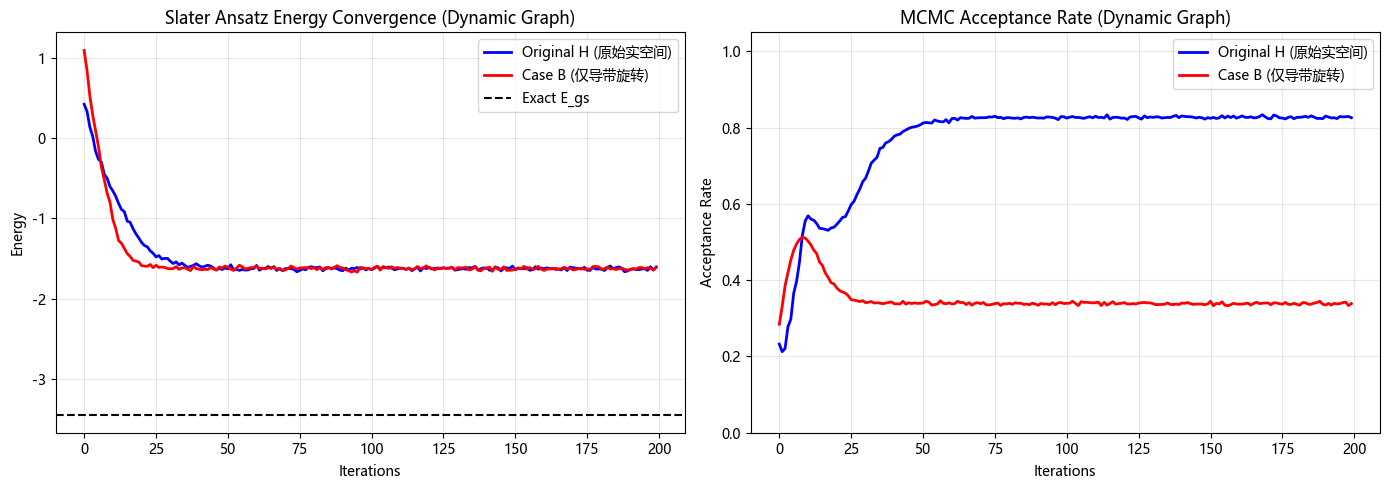

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 0. 修复 matplotlib 中文显示与负号问题
# ==============================================================================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# 1. 终极健壮版数据提取函数 (完美兼容方法与属性，修复小写键名)
# ==============================================================================
def extract_log_data(log):
    """从 NetKet 的 RuntimeLog 中提取迭代步数、能量平均值和接受率"""
    iters = np.array(log.data["Energy"].iters)
    
    # --- 1. 提取 Energy ---
    energy_list = []
    for e in log.data["Energy"].values:
        # 兼容 Stats 对象 (mean是属性) 和 NumPy/JAX 数组 (mean是方法)
        if hasattr(e, 'mean'):
            val = e.mean() if callable(e.mean) else e.mean
        elif hasattr(e, 'value'):
            val = e.value() if callable(e.value) else e.value
        else:
            val = float(e)
        energy_list.append(np.real(val))
    energy = np.array(energy_list)
    
    # --- 2. 提取 Acceptance Rate ---
    acceptance = np.zeros_like(energy) # 默认数组，防空
    
    # 查找接收率的键名 (增加对小写 acceptance 的支持)
    if "acceptance" in log.data:
        raw_acc = log.data["acceptance"].values
    elif "Acceptance" in log.data:
        raw_acc = log.data["Acceptance"].values
    elif "Acceptance_Rate" in log.data:
        raw_acc = log.data["Acceptance_Rate"].values
    else:
        raw_acc = []
        
    if len(raw_acc) > 0:
        acc_list = []
        for a in raw_acc:
            if hasattr(a, 'mean'):
                val = a.mean() if callable(a.mean) else a.mean
            elif hasattr(a, 'value'):
                val = a.value() if callable(a.value) else a.value
            else:
                val = float(a)
            acc_list.append(np.real(val))
        acceptance = np.array(acc_list)
            
    return iters, energy, acceptance

# 提取 Slater 行列式 + 动态图采样 的两组实验数据
it_orig_dyn, E_orig_dyn, acc_orig_dyn = extract_log_data(log_orig_dyn)
it_B_dyn,    E_B_dyn,    acc_B_dyn    = extract_log_data(log_B_dyn)

# ==============================================================================
# 2. 绘制对比图表
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# 图 1: 能量收敛曲线 (Energy vs Iterations)
# ---------------------------------------------------------
ax1.plot(it_orig_dyn, E_orig_dyn, label='Original H (原始实空间)', color='blue', linewidth=2)
ax1.plot(it_B_dyn,    E_B_dyn,    label='Case B (仅导带旋转)', color='red', linewidth=2)

# 画出精确的基态能量参考线 (如果 E_gs 有效)
if 'E_gs' in globals() and E_gs != 0.0:
    ax1.axhline(y=E_gs, color='black', linestyle='--', label='Exact E_gs')

ax1.set_xlabel('Iterations')
ax1.set_ylabel('Energy')
ax1.set_title('Slater Ansatz Energy Convergence (Dynamic Graph)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ---------------------------------------------------------
# 图 2: 采样接受率 (Acceptance Rate vs Iterations)
# ---------------------------------------------------------
ax2.plot(it_orig_dyn, acc_orig_dyn, label='Original H (原始实空间)', color='blue', linewidth=2)
ax2.plot(it_B_dyn,    acc_B_dyn,    label='Case B (仅导带旋转)', color='red', linewidth=2)

ax2.set_xlabel('Iterations')
ax2.set_ylabel('Acceptance Rate')
ax2.set_title('MCMC Acceptance Rate (Dynamic Graph)')
ax2.set_ylim(0, 1.05) # 接受率理论上在 0 到 1 之间
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Neural Jastrow-Slater

在 Slater 振幅外再乘一个神经网络 Jastrow 因子：
$ \log\Psi(\mathbf{n}) = \log\Phi_{\mathrm{Slater}}(\mathbf{n}) + J_\theta(\mathbf{n}) $.

它主要增强相关性描述（尤其是振幅模值部分）。

In [87]:
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = N

    @nn.compact
    def __call__(self, n):
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=False, param_dtype=float
        )(n)

        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        return log_slater + j

model_nj = LogNeuralJastrowSlater(hi, hidden_units=min(1, 2 * n_orbitals))
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,
    sampler_seed=SEED_SAMPLER_NJ,
 )
nj_p = vstate_nj.n_parameters
print(f" [NJ] Params: {nj_p}")

op_nj = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj = nk.driver.VMC_SR(
    H, op_nj, variational_state=vstate_nj, diag_shift=0.05, mode="real"
 )

nj_log = nk.logging.RuntimeLog()
gs_nj.run(n_iter=200, out=nj_log)

E_nj = vstate_nj.expect(H)
err_nj = abs((E_nj.mean - E_gs) / E_gs)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")
print(f"Neural Jastrow-Slater relative error  : {err_nj}")

 [NJ] Params: 27
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [00:12<00:00, 16.38it/s, Energy=-3.43894-0.00000j ± 0.00014 [σ²=7.7e-05, R̂=1.002]]


Neural Jastrow-Slater optimized energy: -3.43897+0.00000j ± 0.00014 [σ²=6.9e-05, R̂=1.002]
Neural Jastrow-Slater relative error  : 0.002461296893436564


>>> [Cell 4] 可视化 Jastrow 因子的实空间轨道权重 (Spatial Attention)
提取到的权重矩阵形状: (8, 1) (轨道数: 8, 隐藏节点数: 1)


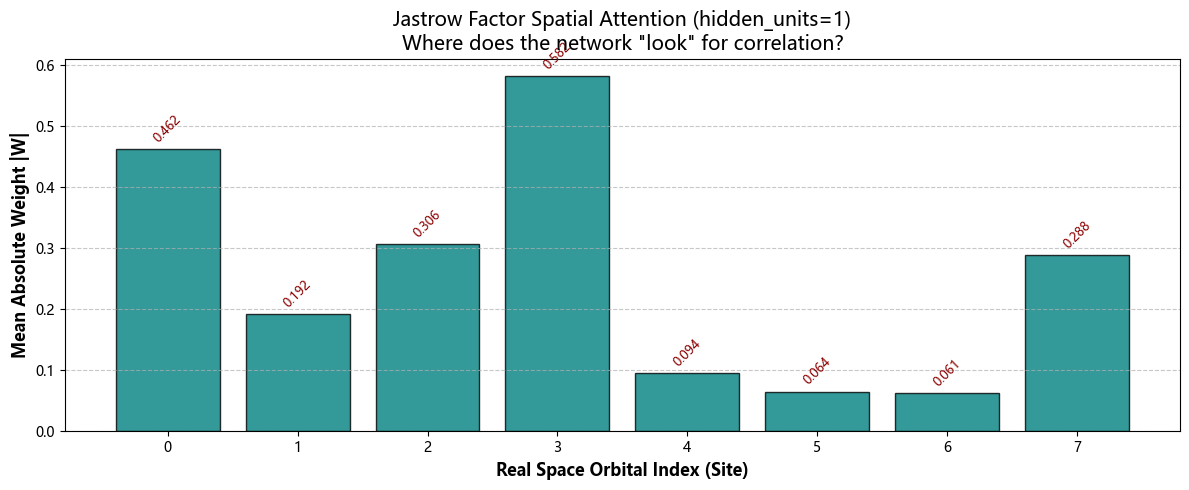

In [88]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 4] 可视化 Jastrow 因子的实空间轨道权重 (Spatial Attention)")
print("=" * 70)

# ==============================================================================
# 1. 提取变分态的参数
# ==============================================================================
params = vstate_nj.parameters

# Flax 默认把第一个 nn.Dense 命名为 'Dense_0'
# 这里的 kernel 矩阵形状是 (n_orbitals, hidden_units)
try:
    w_kernel = np.array(params['Dense_0']['kernel'])
except KeyError:
    # 兼容性备用方案：如果网络结构被稍微包裹过，尝试模糊获取
    layer_keys = list(params.keys())
    w_kernel = np.array(params[layer_keys[0]]['kernel'])

n_orb, h_units = w_kernel.shape
print(f"提取到的权重矩阵形状: {w_kernel.shape} (轨道数: {n_orb}, 隐藏节点数: {h_units})")

# ==============================================================================
# 2. 计算空间注意力 (Spatial Attention)
# ==============================================================================
# 计算每个实空间格点连接到所有隐藏节点的“平均绝对权重”。
# 值越大，说明 Jastrow 因子越“死盯着”这个格点来施加多体关联惩罚。
site_importance = np.mean(np.abs(w_kernel), axis=1)

# ==============================================================================
# 3. 绘制实空间权重分布图
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 5))

# 绘制柱状图
bars = ax.bar(range(n_orb), site_importance, color='teal', alpha=0.8, edgecolor='black')

ax.set_xlabel('Real Space Orbital Index (Site)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Absolute Weight |W|', fontsize=12, fontweight='bold')
ax.set_title(f'Jastrow Factor Spatial Attention (hidden_units={h_units})\nWhere does the network "look" for correlation?', fontsize=14)
ax.set_xticks(range(n_orb))
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 在显著的柱子上标注具体数值 (过滤掉接近 0 的废弃轨道)
threshold = np.max(site_importance) * 0.1  # 只标注最大权重 10% 以上的柱子
for idx, bar in enumerate(bars):
    height = bar.get_height()
    if height > threshold:
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 垂直偏移 3 个像素
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, rotation=45, color='darkred')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 4] 可视化 Jastrow 因子的实空间轨道权重 (Spatial Attention)")
print("=" * 70)

# ==============================================================================
# 1. 提取变分态的参数
# ==============================================================================
params = vstate_nj.parameters

# Flax 默认把第一个 nn.Dense 命名为 'Dense_0'
# 这里的 kernel 矩阵形状是 (n_orbitals, hidden_units)
try:
    w_kernel = np.array(params['Dense_0']['kernel'])
except KeyError:
    # 兼容性备用方案：如果网络结构被稍微包裹过，尝试模糊获取
    layer_keys = list(params.keys())
    w_kernel = np.array(params[layer_keys[0]]['kernel'])

n_orb, h_units = w_kernel.shape
print(f"提取到的权重矩阵形状: {w_kernel.shape} (轨道数: {n_orb}, 隐藏节点数: {h_units})")

# ==============================================================================
# 2. 计算空间注意力 (Spatial Attention)
# ==============================================================================
# 计算每个实空间格点连接到所有隐藏节点的“平均绝对权重”。
# 值越大，说明 Jastrow 因子越“死盯着”这个格点来施加多体关联惩罚。
site_importance = np.mean(np.abs(w_kernel), axis=1)

# ==============================================================================
# 3. 绘制实空间权重分布图
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 5))

# 绘制柱状图
bars = ax.bar(range(n_orb), site_importance, color='teal', alpha=0.8, edgecolor='black')

ax.set_xlabel('Real Space Orbital Index (Site)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Absolute Weight |W|', fontsize=12, fontweight='bold')
ax.set_title(f'Jastrow Factor Spatial Attention (hidden_units={h_units})\nWhere does the network "look" for correlation?', fontsize=14)
ax.set_xticks(range(n_orb))
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 在显著的柱子上标注具体数值 (过滤掉接近 0 的废弃轨道)
threshold = np.max(site_importance) * 0.1  # 只标注最大权重 10% 以上的柱子
for idx, bar in enumerate(bars):
    height = bar.get_height()
    if height > threshold:
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 垂直偏移 3 个像素
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, rotation=45, color='darkred')

plt.tight_layout()
plt.show()

In [26]:
import jax
import jax.numpy as jnp
import netket as nk
import flax.linen as nn

print("=" * 70)
print(">>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)")
print("=" * 70)

# 确保全连接图已存在
if 'graph_complete' not in globals():
    n_orb = hi.n_orbitals
    complete_edges = [(i, j) for i in range(n_orb) for j in range(i + 1, n_orb)]
    graph_complete = nk.graph.Graph(edges=complete_edges)

# ==============================================================================
# 1. 定义 Neural Jastrow-Slater Ansatz
# ==============================================================================
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32  # 设置默认值防止外部 N 未定义

    @nn.compact
    def __call__(self, n):
        # Slater 行列式部分 (反对称性)
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=False, param_dtype=float
        )(n)

        # Jastrow 神经网络部分 (对称的幅度关联)
        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        
        return log_slater + j

hidden_dim = min(1, 2 * hi.n_orbitals)
print(f"Neural Jastrow-Slater hidden units: {hidden_dim}")

# ==============================================================================
# 2. Original H - NJ 优化 (全连接图)
# ==============================================================================
print(">>> 正在优化 Original H (原始实空间) [Complete Graph] ...")
model_nj_orig_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
sa_nj_orig_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_nj_orig_comp = nk.vqs.MCState(
    sa_nj_orig_comp, model_nj_orig_comp, n_samples=2**12, n_discard_per_chain=16,
    seed=101, sampler_seed=201,
)
print(f" [NJ Original] 参量总数 (Parameters): {vstate_nj_orig_comp.n_parameters}")

op_nj_orig_comp = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_orig_comp = nk.driver.VMC_SR(H_orig_opt, op_nj_orig_comp, variational_state=vstate_nj_orig_comp, diag_shift=0.05, mode="real")

log_nj_orig_comp = nk.logging.RuntimeLog()
gs_nj_orig_comp.run(n_iter=500, out=log_nj_orig_comp)

E_nj_orig_comp = vstate_nj_orig_comp.expect(H_orig_opt)
err_nj_orig_comp = abs((E_nj_orig_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"-> Original (Complete) Energy : {E_nj_orig_comp}")
print(f"-> Original (Complete) Error  : {err_nj_orig_comp:.4e}\n")

# ==============================================================================
# 3. Case A - NJ 优化 (全连接图) —— [已注释]
# ==============================================================================
# print(">>> 正在优化 Case A (全轨道旋转) [Complete Graph] ...")
# model_nj_A_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
# sa_nj_A_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)
# vstate_nj_A_comp = nk.vqs.MCState(sa_nj_A_comp, model_nj_A_comp, n_samples=2**12, n_discard_per_chain=16, seed=102, sampler_seed=202)
# op_nj_A_comp = nk.optimizer.Sgd(learning_rate=0.05)
# gs_nj_A_comp = nk.driver.VMC_SR(H_A_opt, op_nj_A_comp, variational_state=vstate_nj_A_comp, diag_shift=0.05, mode="real")
# log_nj_A_comp = nk.logging.RuntimeLog()
# gs_nj_A_comp.run(n_iter=200, out=log_nj_A_comp)
# E_nj_A_comp = vstate_nj_A_comp.expect(H_A_opt)
# err_nj_A_comp = abs((E_nj_A_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
# print(f"-> Case A (Complete) Energy : {E_nj_A_comp}")
# print(f"-> Case A (Complete) Error  : {err_nj_A_comp:.4e}\n")

# ==============================================================================
# 4. Case B - NJ 优化 (全连接图)
# ==============================================================================
print(">>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...")
model_nj_B_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
sa_nj_B_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_nj_B_comp = nk.vqs.MCState(
    sa_nj_B_comp, model_nj_B_comp, n_samples=2**12, n_discard_per_chain=16,
    seed=103, sampler_seed=203,
)
print(f" [NJ Case B] 参量总数 (Parameters): {vstate_nj_B_comp.n_parameters}")

op_nj_B_comp = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_B_comp = nk.driver.VMC_SR(H_B_opt, op_nj_B_comp, variational_state=vstate_nj_B_comp, diag_shift=0.05, mode="real")

log_nj_B_comp = nk.logging.RuntimeLog()
gs_nj_B_comp.run(n_iter=500, out=log_nj_B_comp)

E_nj_B_comp = vstate_nj_B_comp.expect(H_B_opt)
err_nj_B_comp = abs((E_nj_B_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"-> Case B (Complete) Energy : {E_nj_B_comp}")
print(f"-> Case B (Complete) Error  : {err_nj_B_comp:.4e}\n")

print("=" * 70)
print("Complete Graph - Jastrow-Slater Summary:")
print(f"Original H Error : {err_nj_orig_comp:.4e}")
print(f"Case B Error     : {err_nj_B_comp:.4e}")
print("=" * 70)

>>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)
Neural Jastrow-Slater hidden units: 1
>>> 正在优化 Original H (原始实空间) [Complete Graph] ...
 [NJ Original] 参量总数 (Parameters): 83
Automatic SR implementation choice:  QGT


100%|██████████| 500/500 [01:30<00:00,  5.54it/s, Energy=-2.955849-0.000000j ± 0.000083 [σ²=2.5e-05, R̂=1.002]]


-> Original (Complete) Energy : -2.955850-0.000000j ± 0.000097 [σ²=3.9e-05, R̂=1.002]
-> Original (Complete) Error  : 7.6600e-04

>>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...
 [NJ Case B] 参量总数 (Parameters): 83
Automatic SR implementation choice:  QGT


100%|██████████| 500/500 [02:03<00:00,  4.05it/s, Energy=-2.94975-0.00000j ± 0.00035 [σ²=2.5e-04, R̂=1.013]]      


-> Case B (Complete) Energy : -2.94994+0.00000j ± 0.00028 [σ²=1.9e-04, R̂=1.004]
-> Case B (Complete) Error  : 2.7625e-03

Complete Graph - Jastrow-Slater Summary:
Original H Error : 7.6600e-04
Case B Error     : 2.7625e-03


>>> [Cell 2] 绘制 MCMC 统计动力学全景诊断图 (Energy, Acc, Tau, R_hat)


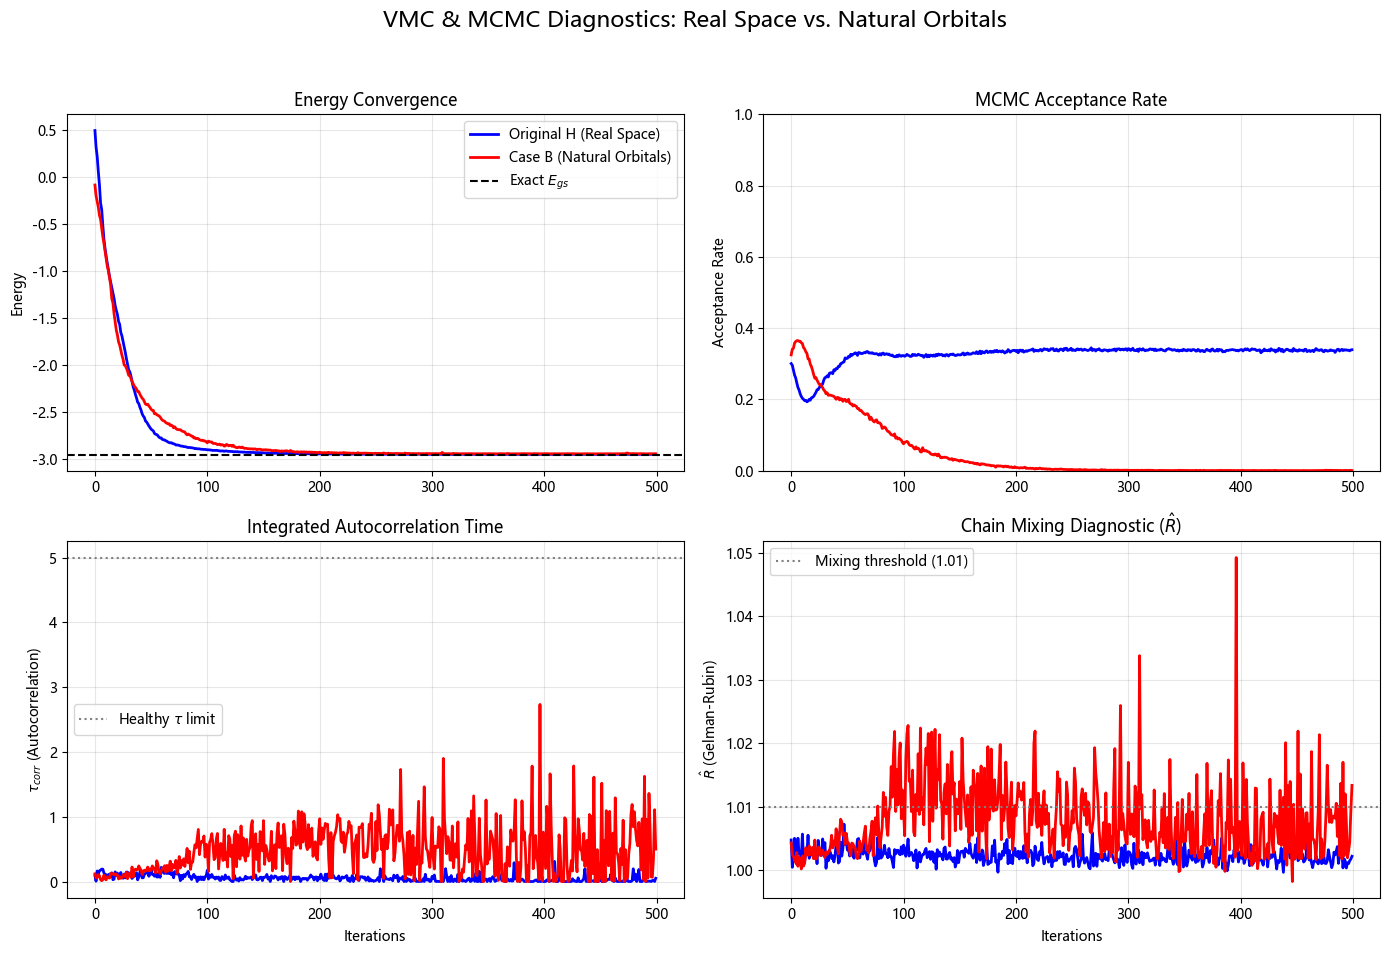

In [27]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 2] 绘制 MCMC 统计动力学全景诊断图 (Energy, Acc, Tau, R_hat)")
print("=" * 70)

# ==============================================================================
# 1. 从 RuntimeLog 中提取数据 (修复语法与版本兼容问题)
# ==============================================================================
# 提取迭代步数
iters = log_nj_orig_comp.data['Energy'].iters

# 自动兼容 NetKet 不同版本的接受率键名 (大小写容错)
acc_key = 'Acceptance' if 'Acceptance' in log_nj_orig_comp.data else 'acceptance'

# 提取 Original H (实空间) 的数据
# 注意：NetKet 要求使用字典语法 ['Mean'] 提取具体的统计量
E_orig = log_nj_orig_comp.data['Energy']['Mean']
acc_orig = log_nj_orig_comp.data[acc_key]['value']
tau_orig = log_nj_orig_comp.data['Energy']['TauCorr']
rhat_orig = log_nj_orig_comp.data['Energy']['R_hat']

# 提取 Case B (自然轨道/导带旋转) 的数据
E_B = log_nj_B_comp.data['Energy']['Mean']
acc_B = log_nj_B_comp.data[acc_key]['value']
tau_B = log_nj_B_comp.data['Energy']['TauCorr']
rhat_B = log_nj_B_comp.data['Energy']['R_hat']

# ==============================================================================
# 2. 绘制 2x2 面板
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VMC & MCMC Diagnostics: Real Space vs. Natural Orbitals', fontsize=16)

# --- Subplot 1: Energy Convergence ---
axs[0, 0].plot(iters, E_orig, label='Original H (Real Space)', color='blue', linewidth=2)
axs[0, 0].plot(iters, E_B, label='Case B (Natural Orbitals)', color='red', linewidth=2)
if 'E_gs' in globals() and E_gs != 0:
    axs[0, 0].axhline(y=E_gs, color='black', linestyle='--', label='Exact $E_{gs}$')
axs[0, 0].set_ylabel('Energy')
axs[0, 0].set_title('Energy Convergence')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# --- Subplot 2: Acceptance Rate ---
axs[0, 1].plot(iters, acc_orig, color='blue', linewidth=2)
axs[0, 1].plot(iters, acc_B, color='red', linewidth=2)
axs[0, 1].set_ylabel('Acceptance Rate')
axs[0, 1].set_title('MCMC Acceptance Rate')
axs[0, 1].set_ylim(0, 1.0)
axs[0, 1].grid(alpha=0.3)

# --- Subplot 3: Autocorrelation Time (Tau) ---
axs[1, 0].plot(iters, tau_orig, color='blue', linewidth=2)
axs[1, 0].plot(iters, tau_B, color='red', linewidth=2)
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('$\\tau_{corr}$ (Autocorrelation)')
axs[1, 0].set_title('Integrated Autocorrelation Time')
# 画一条 tau = 5 的健康基准线
axs[1, 0].axhline(y=5, color='gray', linestyle=':', label='Healthy $\\tau$ limit') 
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

# --- Subplot 4: Gelman-Rubin R_hat ---
axs[1, 1].plot(iters, rhat_orig, color='blue', linewidth=2)
axs[1, 1].plot(iters, rhat_B, color='red', linewidth=2)
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('$\\hat{R}$ (Gelman-Rubin)')
axs[1, 1].set_title('Chain Mixing Diagnostic ($\\hat{R}$)')
# 画一条 R_hat = 1.01 的健康基准线
axs[1, 1].axhline(y=1.01, color='gray', linestyle=':', label='Mixing threshold (1.01)')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [22]:
import jax
import jax.numpy as jnp
import netket as nk
import flax.linen as nn

print("=" * 70)
print(">>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)")
print("=" * 70)

# 确保全连接图已存在
if 'graph_complete' not in globals():
    n_orb = hi.n_orbitals
    complete_edges = [(i, j) for i in range(n_orb) for j in range(i + 1, n_orb)]
    graph_complete = nk.graph.Graph(edges=complete_edges)

# ==============================================================================
# 1. 定义 Neural Jastrow-Slater Ansatz
# ==============================================================================
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32  # 设置默认值防止外部 N 未定义

    @nn.compact
    def __call__(self, n):
        # Slater 行列式部分 (反对称性)
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

        # Jastrow 神经网络部分 (对称的幅度关联)
        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        
        return log_slater + j

hidden_dim = min(2, 2 * hi.n_orbitals)
print(f"Neural Jastrow-Slater hidden units: {hidden_dim}")

# ==============================================================================
# 2. Original H - NJ 优化 (全连接图)
# ==============================================================================
print(">>> 正在优化 Original H (原始实空间) [Complete Graph] ...")
model_nj_orig_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
sa_nj_orig_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_nj_orig_comp = nk.vqs.MCState(
    sa_nj_orig_comp, model_nj_orig_comp, n_samples=2**14, n_discard_per_chain=16,
    seed=101, sampler_seed=201,
)
print(f" [NJ Original] 参量总数 (Parameters): {vstate_nj_orig_comp.n_parameters}")

op_nj_orig_comp = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_orig_comp = nk.driver.VMC_SR(H_orig_opt, op_nj_orig_comp, variational_state=vstate_nj_orig_comp, diag_shift=0.05, mode="real")

log_nj_orig_comp = nk.logging.RuntimeLog()
gs_nj_orig_comp.run(n_iter=200, out=log_nj_orig_comp)

E_nj_orig_comp = vstate_nj_orig_comp.expect(H_orig_opt)
err_nj_orig_comp = abs((E_nj_orig_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"-> Original (Complete) Energy : {E_nj_orig_comp}")
print(f"-> Original (Complete) Error  : {err_nj_orig_comp:.4e}\n")

# ==============================================================================
# 3. Case A - NJ 优化 (全连接图) —— [已注释]
# ==============================================================================
# print(">>> 正在优化 Case A (全轨道旋转) [Complete Graph] ...")
# model_nj_A_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
# sa_nj_A_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)
# vstate_nj_A_comp = nk.vqs.MCState(sa_nj_A_comp, model_nj_A_comp, n_samples=2**12, n_discard_per_chain=16, seed=102, sampler_seed=202)
# op_nj_A_comp = nk.optimizer.Sgd(learning_rate=0.05)
# gs_nj_A_comp = nk.driver.VMC_SR(H_A_opt, op_nj_A_comp, variational_state=vstate_nj_A_comp, diag_shift=0.05, mode="real")
# log_nj_A_comp = nk.logging.RuntimeLog()
# gs_nj_A_comp.run(n_iter=200, out=log_nj_A_comp)
# E_nj_A_comp = vstate_nj_A_comp.expect(H_A_opt)
# err_nj_A_comp = abs((E_nj_A_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
# print(f"-> Case A (Complete) Energy : {E_nj_A_comp}")
# print(f"-> Case A (Complete) Error  : {err_nj_A_comp:.4e}\n")

# ==============================================================================
# 4. Case B - NJ 优化 (全连接图)
# ==============================================================================
print(">>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...")
model_nj_B_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
sa_nj_B_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_nj_B_comp = nk.vqs.MCState(
    sa_nj_B_comp, model_nj_B_comp, n_samples=2**14, n_discard_per_chain=16,
    seed=103, sampler_seed=203,
)
print(f" [NJ Case B] 参量总数 (Parameters): {vstate_nj_B_comp.n_parameters}")

op_nj_B_comp = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_B_comp = nk.driver.VMC_SR(H_B_opt, op_nj_B_comp, variational_state=vstate_nj_B_comp, diag_shift=0.05, mode="real")

log_nj_B_comp = nk.logging.RuntimeLog()
gs_nj_B_comp.run(n_iter=200, out=log_nj_B_comp)

E_nj_B_comp = vstate_nj_B_comp.expect(H_B_opt)
err_nj_B_comp = abs((E_nj_B_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"-> Case B (Complete) Energy : {E_nj_B_comp}")
print(f"-> Case B (Complete) Error  : {err_nj_B_comp:.4e}\n")

print("=" * 70)
print("Complete Graph - Jastrow-Slater Summary:")
print(f"Original H Error : {err_nj_orig_comp:.4e}")
print(f"Case B Error     : {err_nj_B_comp:.4e}")
print("=" * 70)

>>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)
Neural Jastrow-Slater hidden units: 2
>>> 正在优化 Original H (原始实空间) [Complete Graph] ...
 [NJ Original] 参量总数 (Parameters): 69
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [02:41<00:00,  1.24it/s, Energy=-2.95165-0.00000j ± 0.00093 [σ²=1.4e-02, R̂=1.000]]


-> Original (Complete) Energy : -2.94989-0.00000j ± 0.00066 [σ²=7.3e-03, R̂=1.001]
-> Original (Complete) Error  : 2.7809e-03

>>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...
 [NJ Case B] 参量总数 (Parameters): 69
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [02:54<00:00,  1.14it/s, Energy=-2.94603+0.00000j ± 0.00091 [σ²=7.0e-03, R̂=1.001]]


-> Case B (Complete) Energy : -2.94793-0.00000j ± 0.00099 [σ²=1.1e-02, R̂=1.001]
-> Case B (Complete) Error  : 3.4417e-03

Complete Graph - Jastrow-Slater Summary:
Original H Error : 2.7809e-03
Case B Error     : 3.4417e-03


>>> [Cell 2] 绘制 MCMC 统计动力学全景诊断图 (Energy, Acc, Tau, R_hat)


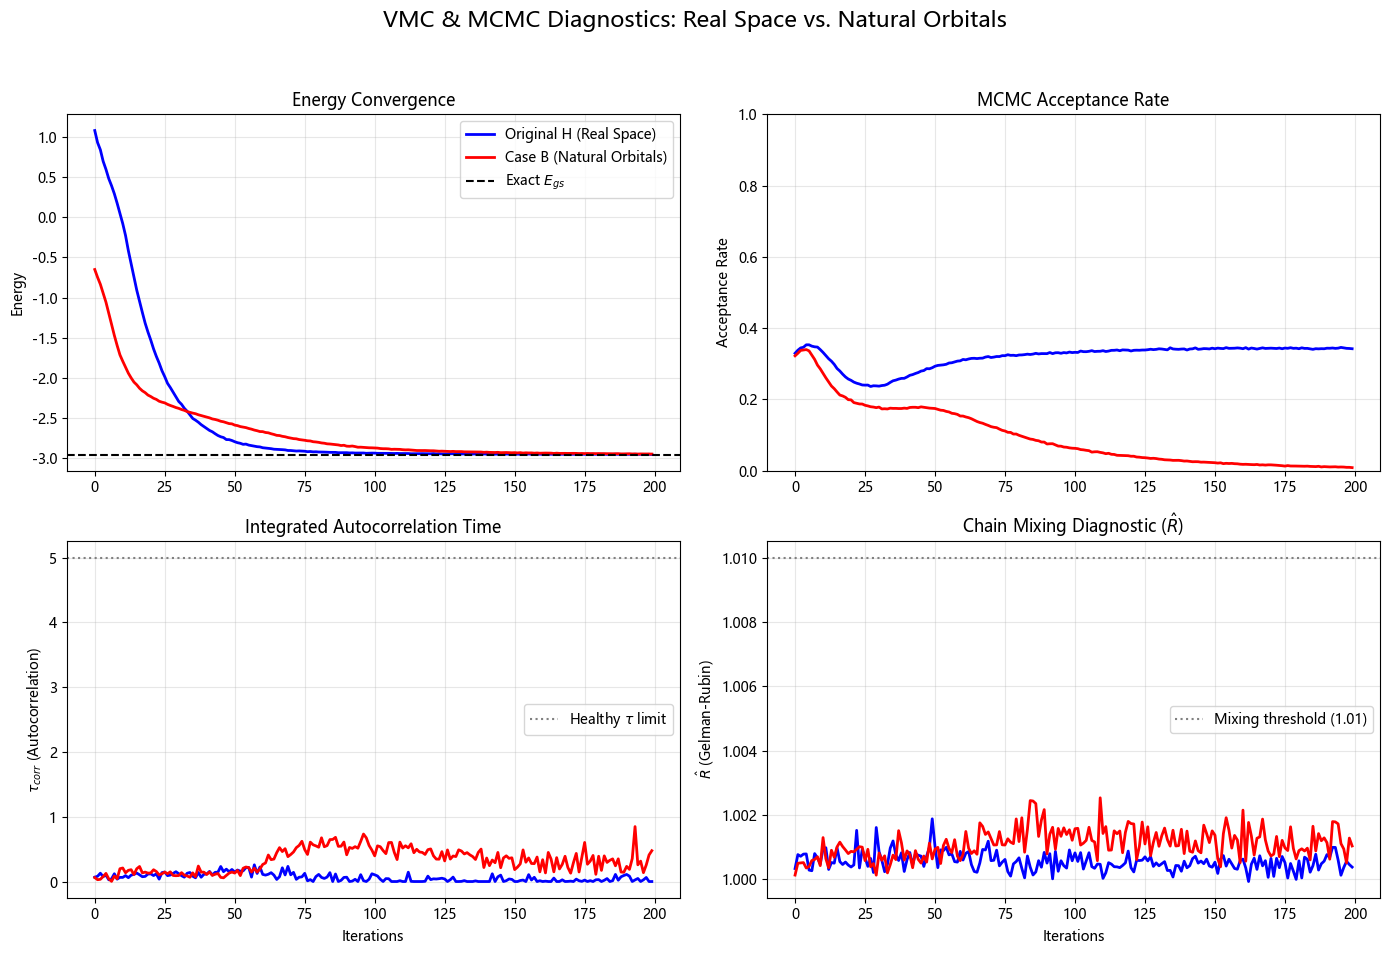

In [23]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 2] 绘制 MCMC 统计动力学全景诊断图 (Energy, Acc, Tau, R_hat)")
print("=" * 70)

# ==============================================================================
# 1. 从 RuntimeLog 中提取数据 (修复语法与版本兼容问题)
# ==============================================================================
# 提取迭代步数
iters = log_nj_orig_comp.data['Energy'].iters

# 自动兼容 NetKet 不同版本的接受率键名 (大小写容错)
acc_key = 'Acceptance' if 'Acceptance' in log_nj_orig_comp.data else 'acceptance'

# 提取 Original H (实空间) 的数据
# 注意：NetKet 要求使用字典语法 ['Mean'] 提取具体的统计量
E_orig = log_nj_orig_comp.data['Energy']['Mean']
acc_orig = log_nj_orig_comp.data[acc_key]['value']
tau_orig = log_nj_orig_comp.data['Energy']['TauCorr']
rhat_orig = log_nj_orig_comp.data['Energy']['R_hat']

# 提取 Case B (自然轨道/导带旋转) 的数据
E_B = log_nj_B_comp.data['Energy']['Mean']
acc_B = log_nj_B_comp.data[acc_key]['value']
tau_B = log_nj_B_comp.data['Energy']['TauCorr']
rhat_B = log_nj_B_comp.data['Energy']['R_hat']

# ==============================================================================
# 2. 绘制 2x2 面板
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VMC & MCMC Diagnostics: Real Space vs. Natural Orbitals', fontsize=16)

# --- Subplot 1: Energy Convergence ---
axs[0, 0].plot(iters, E_orig, label='Original H (Real Space)', color='blue', linewidth=2)
axs[0, 0].plot(iters, E_B, label='Case B (Natural Orbitals)', color='red', linewidth=2)
if 'E_gs' in globals() and E_gs != 0:
    axs[0, 0].axhline(y=E_gs, color='black', linestyle='--', label='Exact $E_{gs}$')
axs[0, 0].set_ylabel('Energy')
axs[0, 0].set_title('Energy Convergence')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# --- Subplot 2: Acceptance Rate ---
axs[0, 1].plot(iters, acc_orig, color='blue', linewidth=2)
axs[0, 1].plot(iters, acc_B, color='red', linewidth=2)
axs[0, 1].set_ylabel('Acceptance Rate')
axs[0, 1].set_title('MCMC Acceptance Rate')
axs[0, 1].set_ylim(0, 1.0)
axs[0, 1].grid(alpha=0.3)

# --- Subplot 3: Autocorrelation Time (Tau) ---
axs[1, 0].plot(iters, tau_orig, color='blue', linewidth=2)
axs[1, 0].plot(iters, tau_B, color='red', linewidth=2)
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('$\\tau_{corr}$ (Autocorrelation)')
axs[1, 0].set_title('Integrated Autocorrelation Time')
# 画一条 tau = 5 的健康基准线
axs[1, 0].axhline(y=5, color='gray', linestyle=':', label='Healthy $\\tau$ limit') 
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

# --- Subplot 4: Gelman-Rubin R_hat ---
axs[1, 1].plot(iters, rhat_orig, color='blue', linewidth=2)
axs[1, 1].plot(iters, rhat_B, color='red', linewidth=2)
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('$\\hat{R}$ (Gelman-Rubin)')
axs[1, 1].set_title('Chain Mixing Diagnostic ($\\hat{R}$)')
# 画一条 R_hat = 1.01 的健康基准线
axs[1, 1].axhline(y=1.01, color='gray', linestyle=':', label='Mixing threshold (1.01)')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [20]:
import jax
import jax.numpy as jnp
import netket as nk
import flax.linen as nn

print("=" * 70)
print(">>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)")
print("=" * 70)

# 确保全连接图已存在
if 'graph_complete' not in globals():
    n_orb = hi.n_orbitals
    complete_edges = [(i, j) for i in range(n_orb) for j in range(i + 1, n_orb)]
    graph_complete = nk.graph.Graph(edges=complete_edges)

# ==============================================================================
# 1. 定义 Neural Jastrow-Slater Ansatz
# ==============================================================================
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32  # 设置默认值防止外部 N 未定义

    @nn.compact
    def __call__(self, n):
        # Slater 行列式部分 (反对称性)
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

        # Jastrow 神经网络部分 (对称的幅度关联)
        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        
        return log_slater + j

hidden_dim = min(4, 2 * hi.n_orbitals)
print(f"Neural Jastrow-Slater hidden units: {hidden_dim}")

# ==============================================================================
# 2. Original H - NJ 优化 (全连接图)
# ==============================================================================
print(">>> 正在优化 Original H (原始实空间) [Complete Graph] ...")
model_nj_orig_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
sa_nj_orig_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_nj_orig_comp = nk.vqs.MCState(
    sa_nj_orig_comp, model_nj_orig_comp, n_samples=2**14, n_discard_per_chain=16,
    seed=101, sampler_seed=201,
)
print(f" [NJ Original] 参量总数 (Parameters): {vstate_nj_orig_comp.n_parameters}")

op_nj_orig_comp = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_orig_comp = nk.driver.VMC_SR(H_orig_opt, op_nj_orig_comp, variational_state=vstate_nj_orig_comp, diag_shift=0.05, mode="real")

log_nj_orig_comp = nk.logging.RuntimeLog()
gs_nj_orig_comp.run(n_iter=200, out=log_nj_orig_comp)

E_nj_orig_comp = vstate_nj_orig_comp.expect(H_orig_opt)
err_nj_orig_comp = abs((E_nj_orig_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"-> Original (Complete) Energy : {E_nj_orig_comp}")
print(f"-> Original (Complete) Error  : {err_nj_orig_comp:.4e}\n")

# ==============================================================================
# 3. Case A - NJ 优化 (全连接图) —— [已注释]
# ==============================================================================
# print(">>> 正在优化 Case A (全轨道旋转) [Complete Graph] ...")
# model_nj_A_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
# sa_nj_A_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)
# vstate_nj_A_comp = nk.vqs.MCState(sa_nj_A_comp, model_nj_A_comp, n_samples=2**12, n_discard_per_chain=16, seed=102, sampler_seed=202)
# op_nj_A_comp = nk.optimizer.Sgd(learning_rate=0.05)
# gs_nj_A_comp = nk.driver.VMC_SR(H_A_opt, op_nj_A_comp, variational_state=vstate_nj_A_comp, diag_shift=0.05, mode="real")
# log_nj_A_comp = nk.logging.RuntimeLog()
# gs_nj_A_comp.run(n_iter=200, out=log_nj_A_comp)
# E_nj_A_comp = vstate_nj_A_comp.expect(H_A_opt)
# err_nj_A_comp = abs((E_nj_A_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
# print(f"-> Case A (Complete) Energy : {E_nj_A_comp}")
# print(f"-> Case A (Complete) Error  : {err_nj_A_comp:.4e}\n")

# ==============================================================================
# 4. Case B - NJ 优化 (全连接图)
# ==============================================================================
print(">>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...")
model_nj_B_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
sa_nj_B_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_nj_B_comp = nk.vqs.MCState(
    sa_nj_B_comp, model_nj_B_comp, n_samples=2**14, n_discard_per_chain=16,
    seed=103, sampler_seed=203,
)
print(f" [NJ Case B] 参量总数 (Parameters): {vstate_nj_B_comp.n_parameters}")

op_nj_B_comp = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_B_comp = nk.driver.VMC_SR(H_B_opt, op_nj_B_comp, variational_state=vstate_nj_B_comp, diag_shift=0.05, mode="real")

log_nj_B_comp = nk.logging.RuntimeLog()
gs_nj_B_comp.run(n_iter=200, out=log_nj_B_comp)

E_nj_B_comp = vstate_nj_B_comp.expect(H_B_opt)
err_nj_B_comp = abs((E_nj_B_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"-> Case B (Complete) Energy : {E_nj_B_comp}")
print(f"-> Case B (Complete) Error  : {err_nj_B_comp:.4e}\n")

print("=" * 70)
print("Complete Graph - Jastrow-Slater Summary:")
print(f"Original H Error : {err_nj_orig_comp:.4e}")
print(f"Case B Error     : {err_nj_B_comp:.4e}")
print("=" * 70)

>>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)
Neural Jastrow-Slater hidden units: 4
>>> 正在优化 Original H (原始实空间) [Complete Graph] ...
 [NJ Original] 参量总数 (Parameters): 105
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [02:14<00:00,  1.49it/s, Energy=-2.95124-0.00000j ± 0.00090 [σ²=1.4e-02, R̂=1.001]]


-> Original (Complete) Energy : -2.95045-0.00000j ± 0.00087 [σ²=1.2e-02, R̂=1.001]
-> Original (Complete) Error  : 2.5919e-03

>>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...
 [NJ Case B] 参量总数 (Parameters): 105
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [03:27<00:00,  1.04s/it, Energy=-2.9413-0.0000j ± 0.0011 [σ²=8.6e-03, R̂=1.002]]   


-> Case B (Complete) Energy : -2.94377-0.00000j ± 0.00083 [σ²=7.8e-03, R̂=1.001]
-> Case B (Complete) Error  : 4.8485e-03

Complete Graph - Jastrow-Slater Summary:
Original H Error : 2.5919e-03
Case B Error     : 4.8485e-03


>>> [Cell 2] 绘制 MCMC 统计动力学全景诊断图 (Energy, Acc, Tau, R_hat)


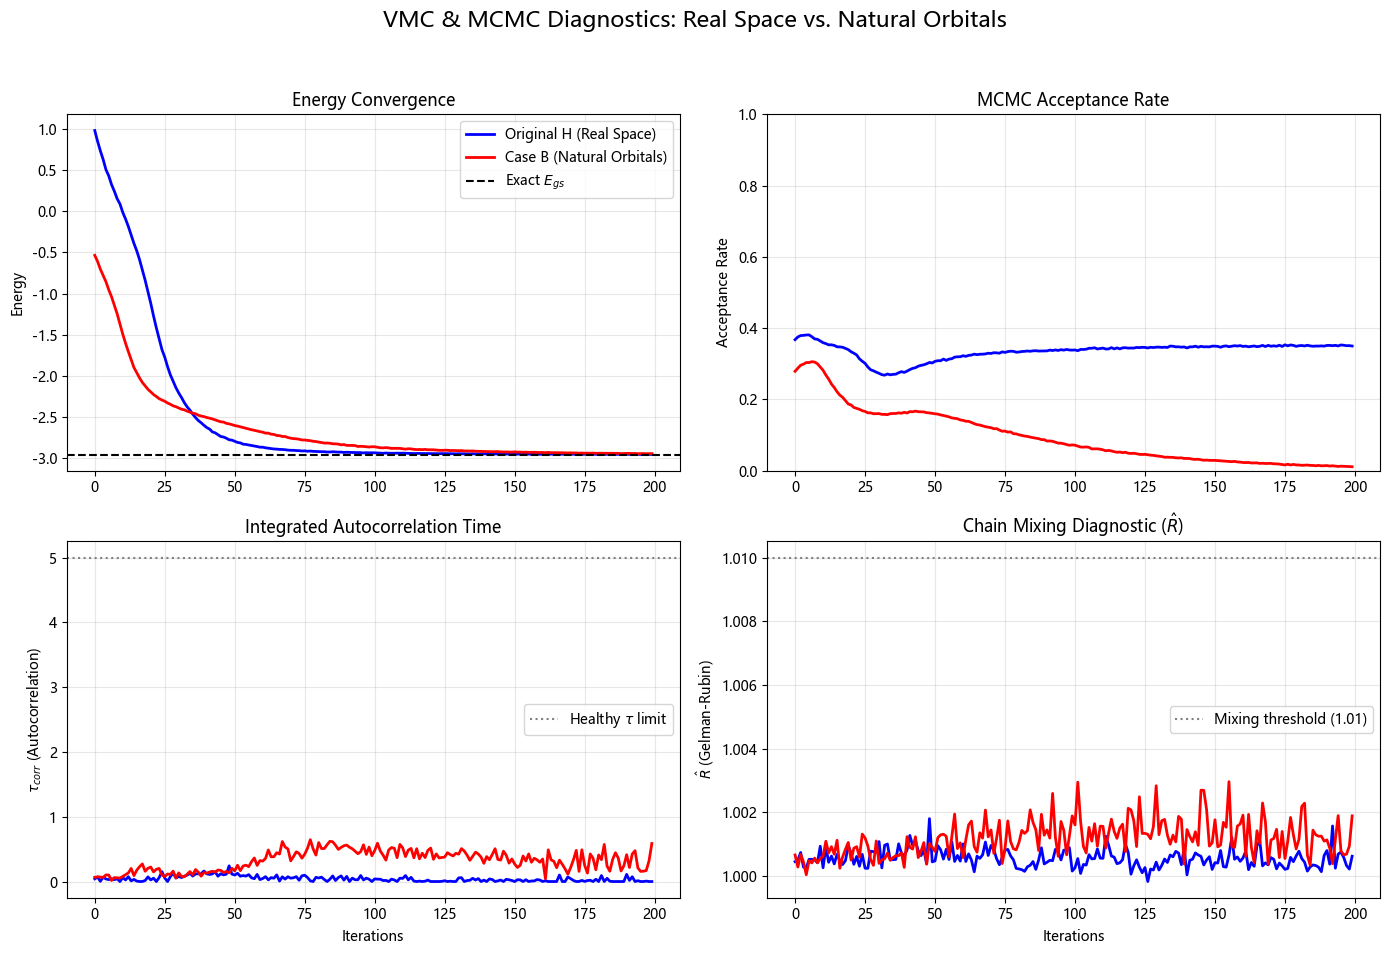

In [21]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 2] 绘制 MCMC 统计动力学全景诊断图 (Energy, Acc, Tau, R_hat)")
print("=" * 70)

# ==============================================================================
# 1. 从 RuntimeLog 中提取数据 (修复语法与版本兼容问题)
# ==============================================================================
# 提取迭代步数
iters = log_nj_orig_comp.data['Energy'].iters

# 自动兼容 NetKet 不同版本的接受率键名 (大小写容错)
acc_key = 'Acceptance' if 'Acceptance' in log_nj_orig_comp.data else 'acceptance'

# 提取 Original H (实空间) 的数据
# 注意：NetKet 要求使用字典语法 ['Mean'] 提取具体的统计量
E_orig = log_nj_orig_comp.data['Energy']['Mean']
acc_orig = log_nj_orig_comp.data[acc_key]['value']
tau_orig = log_nj_orig_comp.data['Energy']['TauCorr']
rhat_orig = log_nj_orig_comp.data['Energy']['R_hat']

# 提取 Case B (自然轨道/导带旋转) 的数据
E_B = log_nj_B_comp.data['Energy']['Mean']
acc_B = log_nj_B_comp.data[acc_key]['value']
tau_B = log_nj_B_comp.data['Energy']['TauCorr']
rhat_B = log_nj_B_comp.data['Energy']['R_hat']

# ==============================================================================
# 2. 绘制 2x2 面板
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VMC & MCMC Diagnostics: Real Space vs. Natural Orbitals', fontsize=16)

# --- Subplot 1: Energy Convergence ---
axs[0, 0].plot(iters, E_orig, label='Original H (Real Space)', color='blue', linewidth=2)
axs[0, 0].plot(iters, E_B, label='Case B (Natural Orbitals)', color='red', linewidth=2)
if 'E_gs' in globals() and E_gs != 0:
    axs[0, 0].axhline(y=E_gs, color='black', linestyle='--', label='Exact $E_{gs}$')
axs[0, 0].set_ylabel('Energy')
axs[0, 0].set_title('Energy Convergence')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# --- Subplot 2: Acceptance Rate ---
axs[0, 1].plot(iters, acc_orig, color='blue', linewidth=2)
axs[0, 1].plot(iters, acc_B, color='red', linewidth=2)
axs[0, 1].set_ylabel('Acceptance Rate')
axs[0, 1].set_title('MCMC Acceptance Rate')
axs[0, 1].set_ylim(0, 1.0)
axs[0, 1].grid(alpha=0.3)

# --- Subplot 3: Autocorrelation Time (Tau) ---
axs[1, 0].plot(iters, tau_orig, color='blue', linewidth=2)
axs[1, 0].plot(iters, tau_B, color='red', linewidth=2)
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('$\\tau_{corr}$ (Autocorrelation)')
axs[1, 0].set_title('Integrated Autocorrelation Time')
# 画一条 tau = 5 的健康基准线
axs[1, 0].axhline(y=5, color='gray', linestyle=':', label='Healthy $\\tau$ limit') 
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

# --- Subplot 4: Gelman-Rubin R_hat ---
axs[1, 1].plot(iters, rhat_orig, color='blue', linewidth=2)
axs[1, 1].plot(iters, rhat_B, color='red', linewidth=2)
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('$\\hat{R}$ (Gelman-Rubin)')
axs[1, 1].set_title('Chain Mixing Diagnostic ($\\hat{R}$)')
# 画一条 R_hat = 1.01 的健康基准线
axs[1, 1].axhline(y=1.01, color='gray', linestyle=':', label='Mixing threshold (1.01)')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import jax
import jax.numpy as jnp
import netket as nk
import flax.linen as nn

print("=" * 70)
print(">>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)")
print("=" * 70)

# 确保全连接图已存在
if 'graph_complete' not in globals():
    n_orb = hi.n_orbitals
    complete_edges = [(i, j) for i in range(n_orb) for j in range(i + 1, n_orb)]
    graph_complete = nk.graph.Graph(edges=complete_edges)

# ==============================================================================
# 1. 定义 Neural Jastrow-Slater Ansatz
# ==============================================================================
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32  # 设置默认值防止外部 N 未定义

    @nn.compact
    def __call__(self, n):
        # Slater 行列式部分 (反对称性)
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

        # Jastrow 神经网络部分 (对称的幅度关联)
        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        
        return log_slater + j

hidden_dim = min(8, 2 * hi.n_orbitals)
print(f"Neural Jastrow-Slater hidden units: {hidden_dim}")

# ==============================================================================
# 2. Original H - NJ 优化 (全连接图)
# ==============================================================================
print(">>> 正在优化 Original H (原始实空间) [Complete Graph] ...")
model_nj_orig_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
sa_nj_orig_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_nj_orig_comp = nk.vqs.MCState(
    sa_nj_orig_comp, model_nj_orig_comp, n_samples=2**14, n_discard_per_chain=16,
    seed=101, sampler_seed=201,
)
print(f" [NJ Original] 参量总数 (Parameters): {vstate_nj_orig_comp.n_parameters}")

op_nj_orig_comp = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_orig_comp = nk.driver.VMC_SR(H_orig_opt, op_nj_orig_comp, variational_state=vstate_nj_orig_comp, diag_shift=0.05, mode="real")

log_nj_orig_comp = nk.logging.RuntimeLog()
gs_nj_orig_comp.run(n_iter=200, out=log_nj_orig_comp)

E_nj_orig_comp = vstate_nj_orig_comp.expect(H_orig_opt)
err_nj_orig_comp = abs((E_nj_orig_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"-> Original (Complete) Energy : {E_nj_orig_comp}")
print(f"-> Original (Complete) Error  : {err_nj_orig_comp:.4e}\n")

# ==============================================================================
# 3. Case A - NJ 优化 (全连接图) —— [已注释]
# ==============================================================================
# print(">>> 正在优化 Case A (全轨道旋转) [Complete Graph] ...")
# model_nj_A_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
# sa_nj_A_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)
# vstate_nj_A_comp = nk.vqs.MCState(sa_nj_A_comp, model_nj_A_comp, n_samples=2**12, n_discard_per_chain=16, seed=102, sampler_seed=202)
# op_nj_A_comp = nk.optimizer.Sgd(learning_rate=0.05)
# gs_nj_A_comp = nk.driver.VMC_SR(H_A_opt, op_nj_A_comp, variational_state=vstate_nj_A_comp, diag_shift=0.05, mode="real")
# log_nj_A_comp = nk.logging.RuntimeLog()
# gs_nj_A_comp.run(n_iter=200, out=log_nj_A_comp)
# E_nj_A_comp = vstate_nj_A_comp.expect(H_A_opt)
# err_nj_A_comp = abs((E_nj_A_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
# print(f"-> Case A (Complete) Energy : {E_nj_A_comp}")
# print(f"-> Case A (Complete) Error  : {err_nj_A_comp:.4e}\n")

# ==============================================================================
# 4. Case B - NJ 优化 (全连接图)
# ==============================================================================
print(">>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...")
model_nj_B_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
sa_nj_B_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_nj_B_comp = nk.vqs.MCState(
    sa_nj_B_comp, model_nj_B_comp, n_samples=2**14, n_discard_per_chain=16,
    seed=103, sampler_seed=203,
)
print(f" [NJ Case B] 参量总数 (Parameters): {vstate_nj_B_comp.n_parameters}")

op_nj_B_comp = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_B_comp = nk.driver.VMC_SR(H_B_opt, op_nj_B_comp, variational_state=vstate_nj_B_comp, diag_shift=0.05, mode="real")

log_nj_B_comp = nk.logging.RuntimeLog()
gs_nj_B_comp.run(n_iter=200, out=log_nj_B_comp)

E_nj_B_comp = vstate_nj_B_comp.expect(H_B_opt)
err_nj_B_comp = abs((E_nj_B_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"-> Case B (Complete) Energy : {E_nj_B_comp}")
print(f"-> Case B (Complete) Error  : {err_nj_B_comp:.4e}\n")

print("=" * 70)
print("Complete Graph - Jastrow-Slater Summary:")
print(f"Original H Error : {err_nj_orig_comp:.4e}")
print(f"Case B Error     : {err_nj_B_comp:.4e}")
print("=" * 70)

>>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)
Neural Jastrow-Slater hidden units: 8
>>> 正在优化 Original H (原始实空间) [Complete Graph] ...
 [NJ Original] 参量总数 (Parameters): 177
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [02:00<00:00,  1.66it/s, Energy=-2.94656-0.00000j ± 0.00051 [σ²=4.7e-03, R̂=1.000]]


-> Original (Complete) Energy : -2.94679-0.00000j ± 0.00077 [σ²=9.6e-03, R̂=1.001]
-> Original (Complete) Error  : 3.8272e-03

>>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...
 [NJ Case B] 参量总数 (Parameters): 177
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [02:44<00:00,  1.22it/s, Energy=-2.94793-0.00000j ± 0.00064 [σ²=4.0e-03, R̂=1.001]]


-> Case B (Complete) Energy : -2.95021-0.00000j ± 0.00061 [σ²=4.4e-03, R̂=1.002]
-> Case B (Complete) Error  : 2.6734e-03

Complete Graph - Jastrow-Slater Summary:
Original H Error : 3.8272e-03
Case B Error     : 2.6734e-03


>>> [Cell 2] 绘制 MCMC 统计动力学全景诊断图 (Energy, Acc, Tau, R_hat)


C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


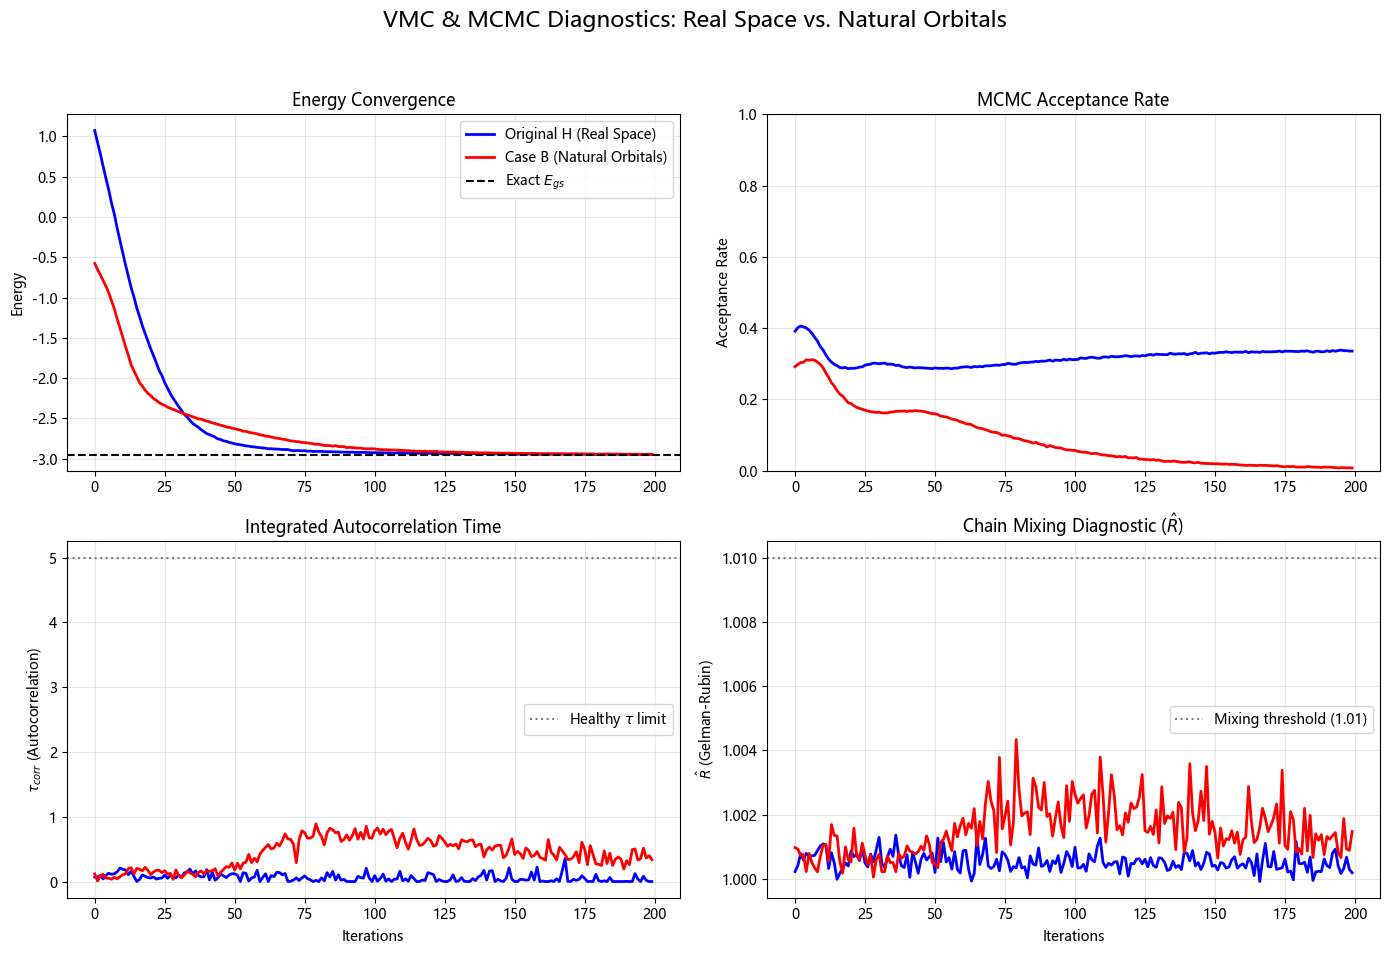

In [19]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 2] 绘制 MCMC 统计动力学全景诊断图 (Energy, Acc, Tau, R_hat)")
print("=" * 70)

# ==============================================================================
# 1. 从 RuntimeLog 中提取数据 (修复语法与版本兼容问题)
# ==============================================================================
# 提取迭代步数
iters = log_nj_orig_comp.data['Energy'].iters

# 自动兼容 NetKet 不同版本的接受率键名 (大小写容错)
acc_key = 'Acceptance' if 'Acceptance' in log_nj_orig_comp.data else 'acceptance'

# 提取 Original H (实空间) 的数据
# 注意：NetKet 要求使用字典语法 ['Mean'] 提取具体的统计量
E_orig = log_nj_orig_comp.data['Energy']['Mean']
acc_orig = log_nj_orig_comp.data[acc_key]['value']
tau_orig = log_nj_orig_comp.data['Energy']['TauCorr']
rhat_orig = log_nj_orig_comp.data['Energy']['R_hat']

# 提取 Case B (自然轨道/导带旋转) 的数据
E_B = log_nj_B_comp.data['Energy']['Mean']
acc_B = log_nj_B_comp.data[acc_key]['value']
tau_B = log_nj_B_comp.data['Energy']['TauCorr']
rhat_B = log_nj_B_comp.data['Energy']['R_hat']

# ==============================================================================
# 2. 绘制 2x2 面板
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VMC & MCMC Diagnostics: Real Space vs. Natural Orbitals', fontsize=16)

# --- Subplot 1: Energy Convergence ---
axs[0, 0].plot(iters, E_orig, label='Original H (Real Space)', color='blue', linewidth=2)
axs[0, 0].plot(iters, E_B, label='Case B (Natural Orbitals)', color='red', linewidth=2)
if 'E_gs' in globals() and E_gs != 0:
    axs[0, 0].axhline(y=E_gs, color='black', linestyle='--', label='Exact $E_{gs}$')
axs[0, 0].set_ylabel('Energy')
axs[0, 0].set_title('Energy Convergence')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# --- Subplot 2: Acceptance Rate ---
axs[0, 1].plot(iters, acc_orig, color='blue', linewidth=2)
axs[0, 1].plot(iters, acc_B, color='red', linewidth=2)
axs[0, 1].set_ylabel('Acceptance Rate')
axs[0, 1].set_title('MCMC Acceptance Rate')
axs[0, 1].set_ylim(0, 1.0)
axs[0, 1].grid(alpha=0.3)

# --- Subplot 3: Autocorrelation Time (Tau) ---
axs[1, 0].plot(iters, tau_orig, color='blue', linewidth=2)
axs[1, 0].plot(iters, tau_B, color='red', linewidth=2)
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('$\\tau_{corr}$ (Autocorrelation)')
axs[1, 0].set_title('Integrated Autocorrelation Time')
# 画一条 tau = 5 的健康基准线
axs[1, 0].axhline(y=5, color='gray', linestyle=':', label='Healthy $\\tau$ limit') 
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

# --- Subplot 4: Gelman-Rubin R_hat ---
axs[1, 1].plot(iters, rhat_orig, color='blue', linewidth=2)
axs[1, 1].plot(iters, rhat_B, color='red', linewidth=2)
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('$\\hat{R}$ (Gelman-Rubin)')
axs[1, 1].set_title('Chain Mixing Diagnostic ($\\hat{R}$)')
# 画一条 R_hat = 1.01 的健康基准线
axs[1, 1].axhline(y=1.01, color='gray', linestyle=':', label='Mixing threshold (1.01)')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [21]:
import jax
import jax.numpy as jnp
import netket as nk
import flax.linen as nn

print("=" * 70)
print(">>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)")
print("=" * 70)

# 确保全连接图已存在
if 'graph_complete' not in globals():
    n_orb = hi.n_orbitals
    complete_edges = [(i, j) for i in range(n_orb) for j in range(i + 1, n_orb)]
    graph_complete = nk.graph.Graph(edges=complete_edges)

# ==============================================================================
# 1. 定义 Neural Jastrow-Slater Ansatz
# ==============================================================================
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32  # 设置默认值防止外部 N 未定义

    @nn.compact
    def __call__(self, n):
        # Slater 行列式部分 (反对称性)
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

        # Jastrow 神经网络部分 (对称的幅度关联)
        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        
        return log_slater + j

hidden_dim = min(32, 2 * hi.n_orbitals)
print(f"Neural Jastrow-Slater hidden units: {hidden_dim}")

# ==============================================================================
# 2. Original H - NJ 优化 (全连接图)
# ==============================================================================
print(">>> 正在优化 Original H (原始实空间) [Complete Graph] ...")
model_nj_orig_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
sa_nj_orig_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_nj_orig_comp = nk.vqs.MCState(
    sa_nj_orig_comp, model_nj_orig_comp, n_samples=2**14, n_discard_per_chain=16,
    seed=101, sampler_seed=201,
)
print(f" [NJ Original] 参量总数 (Parameters): {vstate_nj_orig_comp.n_parameters}")

op_nj_orig_comp = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_orig_comp = nk.driver.VMC_SR(H_orig_opt, op_nj_orig_comp, variational_state=vstate_nj_orig_comp, diag_shift=0.05, mode="real")

log_nj_orig_comp = nk.logging.RuntimeLog()
gs_nj_orig_comp.run(n_iter=200, out=log_nj_orig_comp)

E_nj_orig_comp = vstate_nj_orig_comp.expect(H_orig_opt)
err_nj_orig_comp = abs((E_nj_orig_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"-> Original (Complete) Energy : {E_nj_orig_comp}")
print(f"-> Original (Complete) Error  : {err_nj_orig_comp:.4e}\n")

# ==============================================================================
# 3. Case A - NJ 优化 (全连接图) —— [已注释]
# ==============================================================================
# print(">>> 正在优化 Case A (全轨道旋转) [Complete Graph] ...")
# model_nj_A_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
# sa_nj_A_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)
# vstate_nj_A_comp = nk.vqs.MCState(sa_nj_A_comp, model_nj_A_comp, n_samples=2**12, n_discard_per_chain=16, seed=102, sampler_seed=202)
# op_nj_A_comp = nk.optimizer.Sgd(learning_rate=0.05)
# gs_nj_A_comp = nk.driver.VMC_SR(H_A_opt, op_nj_A_comp, variational_state=vstate_nj_A_comp, diag_shift=0.05, mode="real")
# log_nj_A_comp = nk.logging.RuntimeLog()
# gs_nj_A_comp.run(n_iter=200, out=log_nj_A_comp)
# E_nj_A_comp = vstate_nj_A_comp.expect(H_A_opt)
# err_nj_A_comp = abs((E_nj_A_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
# print(f"-> Case A (Complete) Energy : {E_nj_A_comp}")
# print(f"-> Case A (Complete) Error  : {err_nj_A_comp:.4e}\n")

# ==============================================================================
# 4. Case B - NJ 优化 (全连接图)
# ==============================================================================
print(">>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...")
model_nj_B_comp = LogNeuralJastrowSlater(hi, hidden_units=hidden_dim)
sa_nj_B_comp = nk.sampler.MetropolisFermionHop(hi, graph=graph_complete, spin_symmetric=True)

vstate_nj_B_comp = nk.vqs.MCState(
    sa_nj_B_comp, model_nj_B_comp, n_samples=2**14, n_discard_per_chain=16,
    seed=103, sampler_seed=203,
)
print(f" [NJ Case B] 参量总数 (Parameters): {vstate_nj_B_comp.n_parameters}")

op_nj_B_comp = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_B_comp = nk.driver.VMC_SR(H_B_opt, op_nj_B_comp, variational_state=vstate_nj_B_comp, diag_shift=0.05, mode="real")

log_nj_B_comp = nk.logging.RuntimeLog()
gs_nj_B_comp.run(n_iter=200, out=log_nj_B_comp)

E_nj_B_comp = vstate_nj_B_comp.expect(H_B_opt)
err_nj_B_comp = abs((E_nj_B_comp.mean - E_gs) / E_gs) if E_gs != 0 else float('nan')
print(f"-> Case B (Complete) Energy : {E_nj_B_comp}")
print(f"-> Case B (Complete) Error  : {err_nj_B_comp:.4e}\n")

print("=" * 70)
print("Complete Graph - Jastrow-Slater Summary:")
print(f"Original H Error : {err_nj_orig_comp:.4e}")
print(f"Case B Error     : {err_nj_B_comp:.4e}")
print("=" * 70)

>>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)
Neural Jastrow-Slater hidden units: 16
>>> 正在优化 Original H (原始实空间) [Complete Graph] ...
 [NJ Original] 参量总数 (Parameters): 321
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [03:38<00:00,  1.09s/it, Energy=-2.9506-0.0000j ± 0.0010 [σ²=1.9e-02, R̂=1.000]]   


-> Original (Complete) Energy : -2.9504-0.0000j ± 0.0010 [σ²=1.2e-02, R̂=1.001]
-> Original (Complete) Error  : 2.5992e-03

>>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...
 [NJ Case B] 参量总数 (Parameters): 321
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [06:03<00:00,  1.82s/it, Energy=-2.94264+0.00000j ± 0.00087 [σ²=5.2e-03, R̂=1.004]]


-> Case B (Complete) Energy : -2.94600-0.00000j ± 0.00092 [σ²=8.1e-03, R̂=1.001]
-> Case B (Complete) Error  : 4.0953e-03

Complete Graph - Jastrow-Slater Summary:
Original H Error : 2.5992e-03
Case B Error     : 4.0953e-03


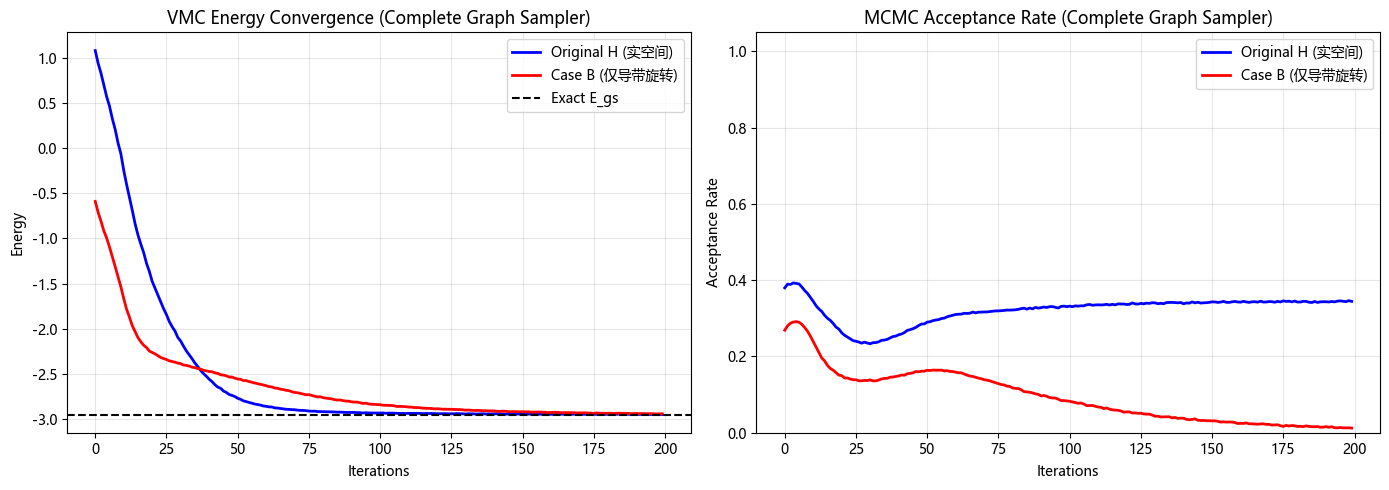

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 0. 修复 matplotlib 中文显示与负号问题
# ==============================================================================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# 1. 终极健壮版数据提取函数 (完美兼容方法与属性，修复小写键名)
# ==============================================================================
def extract_log_data(log):
    """从 NetKet 的 RuntimeLog 中提取迭代步数、能量平均值和接受率"""
    iters = np.array(log.data["Energy"].iters)
    
    # --- 1. 提取 Energy ---
    energy_list = []
    for e in log.data["Energy"].values:
        # 兼容 Stats 对象 (mean是属性) 和 NumPy/JAX 数组 (mean是方法)
        if hasattr(e, 'mean'):
            val = e.mean() if callable(e.mean) else e.mean
        elif hasattr(e, 'value'):
            val = e.value() if callable(e.value) else e.value
        else:
            val = float(e)
        energy_list.append(np.real(val))
    energy = np.array(energy_list)
    
    # --- 2. 提取 Acceptance Rate ---
    acceptance = np.zeros_like(energy) # 默认数组，防空
    
    # 查找接收率的键名 (增加对小写 acceptance 的支持)
    if "acceptance" in log.data:
        raw_acc = log.data["acceptance"].values
    elif "Acceptance" in log.data:
        raw_acc = log.data["Acceptance"].values
    elif "Acceptance_Rate" in log.data:
        raw_acc = log.data["Acceptance_Rate"].values
    else:
        raw_acc = []
        
    if len(raw_acc) > 0:
        acc_list = []
        for a in raw_acc:
            if hasattr(a, 'mean'):
                val = a.mean() if callable(a.mean) else a.mean
            elif hasattr(a, 'value'):
                val = a.value() if callable(a.value) else a.value
            else:
                val = float(a)
            acc_list.append(np.real(val))
        acceptance = np.array(acc_list)
            
    return iters, energy, acceptance

# 仅提取全连接图 (Complete Graph) 的两组实验数据
it_orig_comp, E_orig_comp, acc_orig_comp = extract_log_data(log_nj_orig_comp)
it_B_comp,    E_B_comp,    acc_B_comp    = extract_log_data(log_nj_B_comp)

# ==============================================================================
# 2. 绘制对比图表
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# 图 1: 能量收敛曲线 (Energy vs Iterations)
# ---------------------------------------------------------
ax1.plot(it_orig_comp, E_orig_comp, label='Original H (实空间)', color='blue', linewidth=2)
ax1.plot(it_B_comp,    E_B_comp,    label='Case B (仅导带旋转)', color='red', linewidth=2)

# 画出精确的基态能量参考线 (如果 E_gs 有效)
if 'E_gs' in globals() and E_gs != 0.0:
    ax1.axhline(y=E_gs, color='black', linestyle='--', label='Exact E_gs')

ax1.set_xlabel('Iterations')
ax1.set_ylabel('Energy')
ax1.set_title('VMC Energy Convergence (Complete Graph Sampler)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ---------------------------------------------------------
# 图 2: 采样接受率 (Acceptance Rate vs Iterations)
# ---------------------------------------------------------
ax2.plot(it_orig_comp, acc_orig_comp, label='Original H (实空间)', color='blue', linewidth=2)
ax2.plot(it_B_comp,    acc_B_comp,    label='Case B (仅导带旋转)', color='red', linewidth=2)

ax2.set_xlabel('Iterations')
ax2.set_ylabel('Acceptance Rate')
ax2.set_title('MCMC Acceptance Rate (Complete Graph Sampler)')
ax2.set_ylim(0, 1.05) # 接受率理论上在 0 到 1 之间
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 Neural Backflow

Backflow 的思想是把 Slater 轨道矩阵推广为构型依赖：
$ M^{\mathrm{bf}}(\mathbf{n})=M+F_\theta(\mathbf{n})$ .

下面给出与教程同类型的“加性 backflow”实现：神经网络输出与轨道矩阵同形状的修正项。

In [16]:
class LogNeuralBackflow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = N

    @nn.compact
    def __call__(self, n):
        n_orb = self.hilbert.n_orbitals
        n_spin = self.hilbert.n_spin_subsectors
        nfs = self.hilbert.n_fermions_per_spin[0]

        # 限制型 HF 基轨道（所有自旋扇区共享）
        M = self.param(
            "M",
            nn.initializers.lecun_normal(),
            (n_orb, nfs),
            float,
        )

        # Backflow 网络：输出 (n_spin, n_orb, nfs)
        x = n.astype(jnp.float32)
        F = nn.Dense(self.hidden_units)(x)
        F = jax.nn.tanh(F)
        F = nn.Dense(n_spin * n_orb * nfs)(F)
        F = F.reshape(F.shape[:-1] + (n_spin, n_orb, nfs))

        @partial(jnp.vectorize, signature="(m),(s,o,f)->()")
        def log_bf(n_one, F_one):
            R = n_one.nonzero(size=self.hilbert.n_fermions)[0]
            log_det_sum = 0.0 + 0.0j
            i_start = 0

            for i, nf_i in enumerate(self.hilbert.n_fermions_per_spin):
                if nf_i == 0:
                    continue
                R_i = R[i_start : i_start + nf_i] - i * n_orb
                A_i = (M + F_one[i])[R_i]
                log_det_sum = log_det_sum + nk.jax.logdet_cmplx(A_i)
                i_start += nf_i

            return log_det_sum

        return log_bf(n, F)

model_bf = LogNeuralBackflow(hi, hidden_units=max(32, 2 * n_orbitals))
sa_bf = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_bf = nk.vqs.MCState(
    sa_bf,
    model_bf,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_BF,
    sampler_seed=SEED_SAMPLER_BF,
 )
bf_p = vstate_bf.n_parameters
print(f" [BF] Params: {bf_p}")

op_bf = nk.optimizer.Sgd(learning_rate=0.05)
gs_bf = nk.driver.VMC_SR(
    H, op_bf, variational_state=vstate_bf, diag_shift=0.05, mode="real"
 )

bf_log = nk.logging.RuntimeLog()
gs_bf.run(n_iter=200, out=bf_log)

E_bf = vstate_bf.expect(H)
err_bf = abs((E_bf.mean - E_gs) / E_gs)
print(f"Neural Backflow optimized energy: {E_bf}")
print(f"Neural Backflow relative error  : {err_bf}")

 [BF] Params: 2688
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [02:50<00:00,  1.17it/s, Energy=-2.9387+0.0000j ± 0.0024 [σ²=1.5e-02, R̂=1.006]]


Neural Backflow optimized energy: -2.9405-0.0000j ± 0.0022 [σ²=1.8e-02, R̂=1.005]
Neural Backflow relative error  : 0.005951835179444763


>>> [Cell 1] 启动 Neural Jastrow-Slater 优化 —— 全连接采样图 (Complete Graph)
>>> 正在优化 Original H (原始实空间) [Complete Graph] ...
 [NJ Original] 参量总数 (Parameters): 609
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [01:08<00:00,  2.92it/s, Energy=-2.9476-0.0000j ± 0.0021 [σ²=1.5e-02, R̂=1.004]]   


-> Original (Complete) Energy : -2.9491+0.0000j ± 0.0013 [σ²=5.6e-03, R̂=1.003]
-> Original (Complete) Error  : 3.0360e-03

>>> 正在优化 Case B (仅导带旋转) [Complete Graph] ...
 [NJ Case B] 参量总数 (Parameters): 609
Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [01:23<00:00,  2.38it/s, Energy=-2.9268+0.0000j ± 0.0016 [σ²=5.2e-03, R̂=1.008]]


-> Case B (Complete) Energy : -2.9259-0.0000j ± 0.0016 [σ²=4.9e-03, R̂=1.005]
-> Case B (Complete) Error  : 1.0875e-02

Complete Graph - Jastrow-Slater Summary:
Original H Error : 3.0360e-03
Case B Error     : 1.0875e-02


### 7.4 结果汇总作图

和教程相同，把三种 ansatz 的优化能量曲线放在一张图中，并与 ED 基准能量比较。

C:\Users\10783\AppData\Local\Temp\ipykernel_19180\3704902203.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


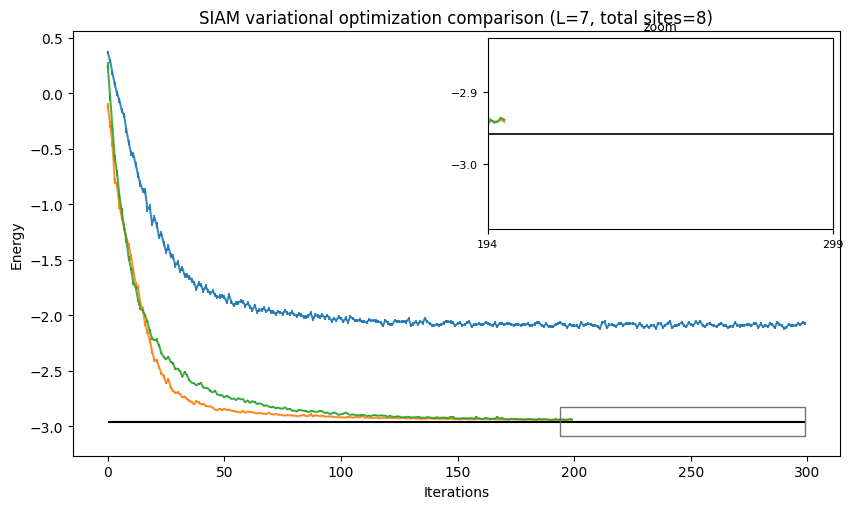

In [17]:
logged_data = (slater_log.data, nj_log.data, bf_log.data)
labels = ("Slater", "Neural Jastrow", "Neural Backflow")

from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(8.6, 5.2))
for data, label in zip(logged_data, labels):
    ax.errorbar(
        data["Energy"].iters,
        data["Energy"].Mean.real,
        yerr=data["Energy"].Sigma,
        label=label,
        alpha=0.85,
    )

iters_max = max(data["Energy"].iters[-1] for data in logged_data)
ax.hlines([E_gs], xmin=0, xmax=iters_max, color="black", label="ED Exact")

ax.set_xlabel("Iterations")
ax.set_ylabel("Energy")
ax.legend()
ax.set_title(f"SIAM variational optimization comparison (L={L}, total sites={n_orbitals})")

# inset: 放大末段迭代与接近 E_gs 的能量窗口
axins = inset_axes(ax, width="45%", height="45%", loc="upper right")
for data, _label in zip(logged_data, labels):
    axins.plot(data["Energy"].iters, data["Energy"].Mean.real, alpha=0.9)
axins.hlines([E_gs], xmin=0, xmax=iters_max, color="black", linewidth=1.2)

# 自动设置放大窗口（后 35% 迭代 + 更窄的 E_gs 邻域）
x1 = int(0.65 * iters_max)
x2 = int(iters_max)
all_means = np.concatenate([np.asarray(d["Energy"].Mean.real) for d in logged_data])
y_center = E_gs
y_span = max(1e-6, 0.04 * np.max(np.abs(all_means - y_center)))
axins.set_xlim(x1, x2)
axins.set_ylim(y_center - y_span, y_center + y_span)
axins.set_xticks([x1, x2])

# 打开并设置 inset 的 y 轴刻度
axins.yaxis.set_major_locator(MaxNLocator(nbins=3))
axins.tick_params(axis="y", labelsize=8)
axins.tick_params(axis="x", labelsize=8)
axins.set_title("zoom", fontsize=9)

# 使用 matplotlib 原生接口标注放大区域，连线更规整
ax.indicate_inset_zoom(axins, edgecolor="0.4", alpha=0.9)

plt.tight_layout()
plt.show()

In [ ]:
# 在此单元中创建三个 operator 别名：H_ref, HA, HB
import numpy as np
from scipy.linalg import block_diag
from netket.operator.fermion import create as cdag, destroy as c, number as nc
# 引用原始 H（已在前面单元构造）
H_ref = globals().get('H', None)
# 辅助函数：从 one-body 矩阵构造 fermion operator（与 Cell 19 中相同）
def build_one_body_operator_from_h(h_mat):
    s = h_mat.shape
    if s == (hi.n_orbitals, hi.n_orbitals):
        h_full = block_diag(h_mat, h_mat)
    elif s == (2 * hi.n_orbitals, 2 * hi.n_orbitals):
        h_full = h_mat
    else:
        raise RuntimeError(f'Unexpected one-body matrix shape {s}')
    Hop = 0.0
    def idx_to_site_spin(idx):
        if idx < hi.n_orbitals:
            return int(idx), +1
        return int(idx - hi.n_orbitals), -1
    for p in range(h_full.shape[0]):
        for q in range(h_full.shape[1]):
            coeff = h_full[p, q]
            if abs(coeff) < 1e-12:
                continue
            sp_p, sz_p = idx_to_site_spin(p)
            sp_q, sz_q = idx_to_site_spin(q)
            Hop += coeff * (cdag(hi, sp_p, sz=sz_p) @ c(hi, sp_q, sz=sz_q))
    return Hop
# 1) HA (Case A)：优先使用已构造的 H_A_op，否则尝试用 h_trans_full + U_spin 构造
if 'H_A_op' in globals():
    HA = H_A_op
else:
    HA = None
    if all(k in globals() for k in ('h_trans_full', 'U_spin', 'transform_meta')):
        hA_one = build_one_body_operator_from_h(h_trans_full)
        imp_up = transform_meta['imp_up']
        imp_dn = transform_meta['imp_dn']
        n_orb = hi.n_orbitals
        n_ob = 2 * n_orb
        up_idxs = np.arange(0, n_orb)
        dn_idxs = np.arange(n_orb, n_ob)
        M_up = np.outer(np.conj(U_spin[imp_up, up_idxs]), U_spin[imp_up, up_idxs])
        M_dn = np.outer(np.conj(U_spin[imp_dn, dn_idxs]), U_spin[imp_dn, dn_idxs])
        n_up_op = 0.0
        for i_p, p_orb in enumerate(up_idxs):
            for i_q, q_orb in enumerate(up_idxs):
                coeff = M_up[i_p, i_q]
                if abs(coeff) < 1e-12:
                    continue
                n_up_op += coeff * (cdag(hi, int(p_orb), sz=+1) @ c(hi, int(q_orb), sz=+1))
        n_dn_op = 0.0
        for i_p, p_spin in enumerate(dn_idxs):
            p_orb = int(p_spin - n_orb)
            for i_q, q_spin in enumerate(dn_idxs):
                q_orb = int(q_spin - n_orb)
                coeff = M_dn[i_p, i_q]
                if abs(coeff) < 1e-12:
                    continue
                n_dn_op += coeff * (cdag(hi, p_orb, sz=-1) @ c(hi, q_orb, sz=-1))
        HA = hA_one + U * (n_up_op - 0.5) @ (n_dn_op - 0.5)
# 2) HB (Case B)：优先使用已构造的 H_B_op，否则用 h_trans_bath + 本地 U 构造
if 'H_B_op' in globals():
    HB = H_B_op
else:
    HB = None
    if 'h_trans_bath' in globals():
        hB_one = build_one_body_operator_from_h(h_trans_bath)
        HB = hB_one + U * (nc(hi, impurity_site, sz=+1) - 0.5) @ (nc(hi, impurity_site, sz=-1) - 0.5)
# 打印结果摘要
print()
print('H_ref exists:', H_ref is not None)
print('HA constructed:', HA is not None)
print('HB constructed:', HB is not None)
# 将别名暴露到全局命名空间
globals()['H_ref'] = H_ref
globals()['HA'] = HA
globals()['HB'] = HB
H_ref = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H_ref)
HA = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(HA)
HB = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(HB)

None
H_ref exists: True
HA constructed: False
HB constructed: False


None
H_ref exists: True
HA constructed: False
HB constructed: False


TypeError: Can only convert to this format an operator of type `<class 'netket.operator._fermion2nd.base.FermionOperator2ndBase'>` but was provided an operator of type `<class 'NoneType'>

In [19]:
# === HB: Slater ===
from scipy.linalg import block_diag
from netket.operator.fermion import create as cdag, destroy as c, number as nc

def build_one_body_operator_from_h(h_mat):
    s = h_mat.shape
    if s == (hi.n_orbitals, hi.n_orbitals):
        h_full = block_diag(h_mat, h_mat)
    elif s == (2 * hi.n_orbitals, 2 * hi.n_orbitals):
        h_full = h_mat
    else:
        raise RuntimeError(f'Unexpected one-body matrix shape {s}')
    Hop = 0.0
    def idx_to_site_spin(idx):
        if idx < hi.n_orbitals:
            return int(idx), +1
        return int(idx - hi.n_orbitals), -1
    for p in range(h_full.shape[0]):
        for q in range(h_full.shape[1]):
            coeff = h_full[p, q]
            if abs(coeff) < 1e-12:
                continue
            sp_p, sz_p = idx_to_site_spin(p)
            sp_q, sz_q = idx_to_site_spin(q)
            Hop += coeff * (cdag(hi, sp_p, sz=sz_p) @ c(hi, sp_q, sz=sz_q))
    return Hop

# If HB missing, try to construct it from available transformed tensors
if 'HB' not in globals():
    if 'H_B_op' in globals():
        HB = H_B_op
        print('Using H_B_op from notebook scope to define HB.')
    elif 'h_trans_bath' in globals():
        print('Constructing HB from h_trans_bath and local U...')
        hB_one = build_one_body_operator_from_h(h_trans_bath)
        HB = hB_one + U * (nc(hi, impurity_site, sz=+1) - 0.5) @ (nc(hi, impurity_site, sz=-1) - 0.5)
        print('HB constructed from h_trans_bath.')
    else:
        raise RuntimeError('HB 未定义；请先运行构造变换的单元（Cell 17）或保证 h_trans_bath/H_B_op 在当前命名空间')
else:
    print('HB found in globals, using existing HB operator.')

model_slater_HB = LogSlaterDeterminant(hi)
sa_slater_HB = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_slater_HB = nk.vqs.MCState(sa_slater_HB, model_slater_HB, n_samples=2**12, n_discard_per_chain=16, seed=SEED_MODEL_SLATER, sampler_seed=SEED_SAMPLER_SLATER)
opt_slater_HB = nk.optimizer.Sgd(learning_rate=0.05)
gs_slater_HB = nk.driver.VMC_SR(HB, opt_slater_HB, variational_state=vstate_slater_HB, diag_shift=0.05, mode='real')
slater_log_HB = nk.logging.RuntimeLog()
gs_slater_HB.run(n_iter=200, out=slater_log_HB)
E_slater_HB = vstate_slater_HB.expect(HB)
print('HB Slater energy:', E_slater_HB)
globals()['vstate_slater_HB'] = vstate_slater_HB
globals()['slater_log_HB'] = slater_log_HB
globals()['E_slater_HB'] = E_slater_HB

HB found in globals, using existing HB operator.
Automatic SR implementation choice:  QGT


  0%|          | 0/200 [00:00<?, ?it/s]

HB found in globals, using existing HB operator.
Automatic SR implementation choice:  QGT


  0%|          | 0/200 [00:00<?, ?it/s]

NotFoundLookupError: `get_local_kernel_arguments(MCState(
  hilbert = SpinOrbitalFermions(n_orbitals=8, s=1/2, n_fermions=8, n_fermions_per_spin=(4, 4)),
  sampler = MetropolisSampler(rule = FermionHopRule(# of clusters: 14), n_chains = 16, sweep_size = 16, 
reset_chains = False, machine_power = 2, dtype = <class 'numpy.int8'>),
  n_samples = 4096,
  n_discard_per_chain = 16,
  sampler_state = MetropolisSamplerState(rng state=Array((), dtype=key<fry>) overlaying:
[3338740573 2957845832]),
  n_parameters = 32), None)` could not be resolved.

Closest candidates are the following:
    get_local_kernel_arguments(vstate: [38;5;248mnetket.vqs.mc.mc_state.state.[0m[1;38;5;248mMCState[0m, Ô: [31mnetket.operator._lazy.[0m[1;31mSquared[0m)     
        <function get_local_kernel_arguments at 0x000001A206DF0360> @                                              
    ]8;id=263580;file://D:\Seafile\PHD\NQS\NetKet\netket\netket\vqs\mc\mc_state\expect.py#43\[37mD:\Seafile\PHD\NQS\NetKet\netke

In [ ]:
# === HB: Neural Jastrow-Slater ===
if 'HB' not in globals():
    raise RuntimeError('HB 未定义；先运行构造变换的单元（Cell 17）')
model_nj_HB = LogNeuralJastrowSlater(hi, hidden_units=max(32, 2 * n_orbitals))
sa_nj_HB = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_nj_HB = nk.vqs.MCState(sa_nj_HB, model_nj_HB, n_samples=2**13, n_discard_per_chain=16, seed=SEED_MODEL_NJ, sampler_seed=SEED_SAMPLER_NJ)
print('[HB NJ] params:', vstate_nj_HB.n_parameters)
opt_nj_HB = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj_HB = nk.driver.VMC_SR(HB, opt_nj_HB, variational_state=vstate_nj_HB, diag_shift=0.05, mode='real')
nj_log_HB = nk.logging.RuntimeLog()
gs_nj_HB.run(n_iter=300, out=nj_log_HB)
E_nj_HB = vstate_nj_HB.expect(HB)
print('HB Neural Jastrow energy:', E_nj_HB)
globals()['vstate_nj_HB'] = vstate_nj_HB
globals()['nj_log_HB'] = nj_log_HB
globals()['E_nj_HB'] = E_nj_HB

In [ ]:
# === HB: Neural Backflow ===
if 'HB' not in globals():
    raise RuntimeError('HB 未定义；先运行构造变换的单元（Cell 17）')
model_bf_HB = LogNeuralBackflow(hi, hidden_units=max(32, 2 * n_orbitals))
sa_bf_HB = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_bf_HB = nk.vqs.MCState(sa_bf_HB, model_bf_HB, n_samples=2**13, n_discard_per_chain=16, seed=SEED_MODEL_BF, sampler_seed=SEED_SAMPLER_BF)
print('[HB BF] params:', vstate_bf_HB.n_parameters)
opt_bf_HB = nk.optimizer.Sgd(learning_rate=0.05)
gs_bf_HB = nk.driver.VMC_SR(HB, opt_bf_HB, variational_state=vstate_bf_HB, diag_shift=0.05, mode='real')
bf_log_HB = nk.logging.RuntimeLog()
gs_bf_HB.run(n_iter=300, out=bf_log_HB)
E_bf_HB = vstate_bf_HB.expect(HB)
print('HB Neural Backflow energy:', E_bf_HB)
globals()['vstate_bf_HB'] = vstate_bf_HB
globals()['bf_log_HB'] = bf_log_HB
globals()['E_bf_HB'] = E_bf_HB

In [31]:
h_trans_full = h_A
V_trans_full = V_A
h_trans_bath = h_B
V_trans_bath = V_B
H_B = h_B + V_B
print(H_B.shape)
model_slater_HB = LogSlaterDeterminant(hi)
sa_slater_HB = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_slater_HB = nk.vqs.MCState(sa_slater_HB, model_slater_HB, n_samples=2**12, n_discard_per_chain=16, seed=SEED_MODEL_SLATER, sampler_seed=SEED_SAMPLER_SLATER)
opt_slater_HB = nk.optimizer.Sgd(learning_rate=0.05)
gs_slater_HB = nk.driver.VMC_SR(HB, opt_slater_HB, variational_state=vstate_slater_HB, diag_shift=0.05, mode='real')
slater_log_HB = nk.logging.RuntimeLog()
gs_slater_HB.run(n_iter=200, out=slater_log_HB)
E_slater_HB = vstate_slater_HB.expect(HB)
print('HB Slater energy:', E_slater_HB)
globals()['vstate_slater_HB'] = vstate_slater_HB
globals()['slater_log_HB'] = slater_log_HB
globals()['E_slater_HB'] = E_slater_HB


(16, 16, 16, 16)
Automatic SR implementation choice:  QGT


  0%|          | 0/200 [00:00<?, ?it/s]

NotFoundLookupError: `get_local_kernel_arguments(MCState(
  hilbert = SpinOrbitalFermions(n_orbitals=8, s=1/2, n_fermions=8, n_fermions_per_spin=(4, 4)),
  sampler = MetropolisSampler(rule = FermionHopRule(# of clusters: 14), n_chains = 16, sweep_size = 16, 
reset_chains = False, machine_power = 2, dtype = <class 'numpy.int8'>),
  n_samples = 4096,
  n_discard_per_chain = 16,
  sampler_state = MetropolisSamplerState(rng state=Array((), dtype=key<fry>) overlaying:
[3338740573 2957845832]),
  n_parameters = 32), None)` could not be resolved.

Closest candidates are the following:
    get_local_kernel_arguments(vstate: [38;5;248mnetket.vqs.mc.mc_state.state.[0m[1;38;5;248mMCState[0m, Ô: [31mnetket.operator._lazy.[0m[1;31mSquared[0m)     
        <function get_local_kernel_arguments at 0x000001A206DF0360> @                                              
    ]8;id=502537;file://D:\Seafile\PHD\NQS\NetKet\netket\netket\vqs\mc\mc_state\expect.py#43\[37mD:\Seafile\PHD\NQS\NetKet\netke